In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

In [12]:
# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("energy_with_temp.csv", sep=";", parse_dates=["TimeStamp"])
df = df.set_index("TimeStamp")
VALUE_COL = "P_HOME"

# Features for XGBoost
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["lag_24"] = df[VALUE_COL].shift(24)
df["lag_48"] = df[VALUE_COL].shift(48)
df["lag_168"] = df[VALUE_COL].shift(168)
df["temperature"] = df["temperature"]  # if available

df = df.dropna()

df = df.loc["2026-01-01":"2026-02-24"]

X = df[["hour","day_of_week","lag_24","lag_48","lag_168","temperature"]]
y = df[VALUE_COL]

# -----------------------------
# Train-test split
# -----------------------------
split = int(len(df)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [16]:
# -----------------------------
# Step 1: SARIMAX for trend/seasonality
# -----------------------------
sarimax_model = SARIMAX(
    y_train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarimax_pred_train = sarimax_model.fittedvalues
sarimax_pred_test = sarimax_model.get_forecast(len(y_test)).predicted_mean

# -----------------------------
# Step 2: Calculate residuals
# -----------------------------
residuals_train = y_train - sarimax_pred_train

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [17]:
# -----------------------------
# Step 3: Train XGBoost on residuals
# -----------------------------
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, residuals_train)

# Predict residuals
residuals_pred_test = xgb_model.predict(X_test)

In [18]:
# -----------------------------
# Step 4: Hybrid forecast
# -----------------------------
hybrid_forecast = sarimax_pred_test + residuals_pred_test

# -----------------------------
# Evaluation
# -----------------------------
mape = mean_absolute_percentage_error(y_test, hybrid_forecast) * 100
print(f"Hybrid model MAPE: {mape:.2f}%")


Hybrid model MAPE: 42.54%


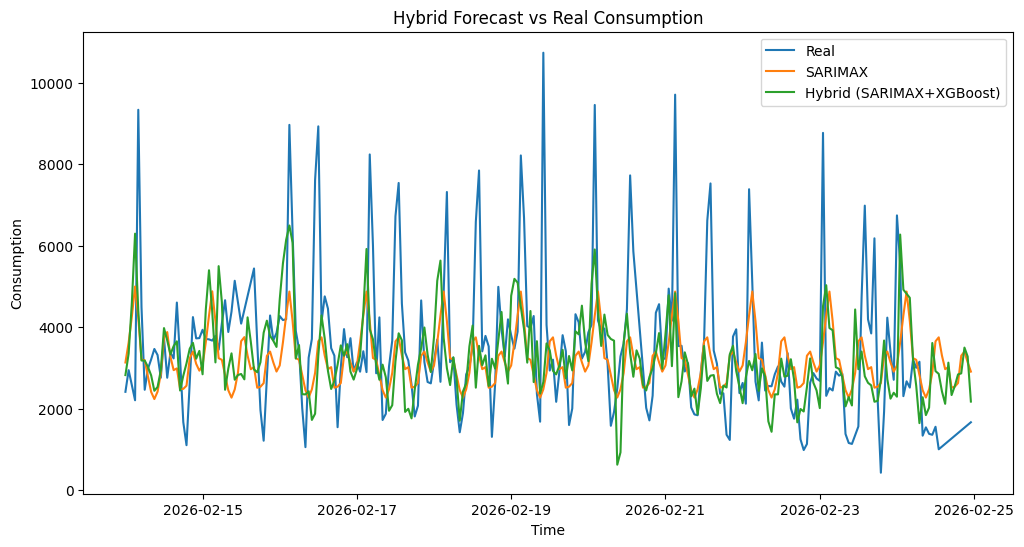

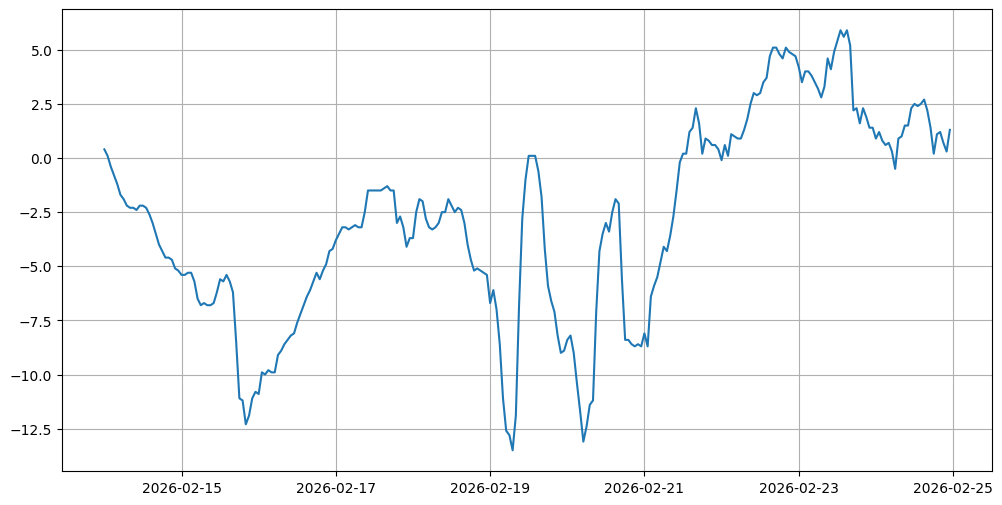

In [19]:
# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, sarimax_pred_test, label="SARIMAX")
plt.plot(y_test.index, hybrid_forecast, label="Hybrid (SARIMAX+XGBoost)")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.title("Hybrid Forecast vs Real Consumption")
plt.legend()

plt.figure(figsize=(12,6))
plt.plot(y_test.index, X_test["temperature"])
plt.grid(True)
plt.show()

In [13]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import itertools
import warnings
from sklearn.model_selection import RandomizedSearchCV

def hybrid_24h_forecast(df, value_col, temperature_col=None, wind_col=None, pressure_col=None, precip_col=None,
                        step_hours=1,
                        future_temp=None, future_wind=None, future_pressure=None, future_precip=None,
                        best_xgb_params=None,
                        best_order=(1,1,2),
                        best_seasonal_order=(1,1,1,24),
                        forecast_shift=0):
    """
    Returns a 24-hour hybrid forecast using SARIMAX + XGBoost residual model.

    Parameters:
    - df: DataFrame with datetime index and columns: value_col, temperature_col
    - value_col: str, name of consumption column
    - temperature_col: str, name of temperature column
    - best_xgb_params: dict, optional XGBoost hyperparameters

    Returns:
    - forecast_df: DataFrame with 24-hour forecast
    """
    df = df.copy()
    agg_dict = {value_col: "sum"}
    use_temp = temperature_col is not None and temperature_col in df.columns
    if use_temp:
        agg_dict[temperature_col] = "mean"
    if wind_col:
        agg_dict[wind_col] = "mean"
    if pressure_col:
        agg_dict[pressure_col] = "mean"
    if precip_col:
        agg_dict[precip_col] = "mean"

    df_resampled = df.resample(f"{step_hours}h").agg(agg_dict)

    # -----------------------------
    # Fill missing values
    # -----------------------------
    df_resampled[value_col] = df_resampled[value_col].interpolate(method='time').ffill().bfill()
    if use_temp:
        df_resampled[temperature_col] = df_resampled[temperature_col].interpolate(method='time').ffill().bfill()
    if wind_col:
        df_resampled[wind_col] = df_resampled[wind_col].interpolate(method='time').ffill().bfill()
    if pressure_col:
        df_resampled[pressure_col] = df_resampled[pressure_col].interpolate(method='time').ffill().bfill()
    if precip_col:
        df_resampled[precip_col] = df_resampled[precip_col].interpolate(method='time').ffill().bfill()
    
    # -----------------------------
    # Add features
    # -----------------------------
    df_resampled['hour'] = df_resampled.index.hour
    df_resampled['is_weekend'] = (df_resampled.index.dayofweek >= 5).astype(int)  # True for Saturday/Sunday

    short_lags=[]
    rolling_windows=[]

    timespan = df.index.max() - df.index.min()
    days = timespan.days
    
    # Short-term lags
    for lag in short_lags:
        df_resampled[f"lag_{lag}"] = df_resampled[value_col].shift(lag)

    # Rolling averages
    for w in rolling_windows:
        df_resampled[f"rolling_{w}"] = df_resampled[value_col].rolling(w).mean()
        
    # Long-term lags
    df_resampled['lag_24'] = df_resampled[value_col].shift(int(24 / step_hours))
    df_resampled['lag_48'] = df_resampled[value_col].shift(int(48 / step_hours))
    if days > 10:
        df_resampled['lag_168'] = df_resampled[value_col].shift(int(168 / step_hours))

    df_resampled = df_resampled.dropna()  # remove rows with insufficient lag history

    # -----------------------------
    # Prepare data
    # -----------------------------
    X_cols = ['hour', 'is_weekend', 'lag_24', 'lag_48'] \
            + [f"lag_{lag}" for lag in short_lags] \
            + [f"rolling_{w}" for w in rolling_windows]
    if use_temp:
        X_cols.append(temperature_col)
    if days > 10:
        X_cols.append('lag_168')
        
    if wind_col:
        X_cols.append(wind_col)
    if pressure_col:
        X_cols.append(pressure_col)
    if precip_col:
        X_cols.append(precip_col)
        
    X = df_resampled[X_cols]
    y = df_resampled[value_col]

    # exog_cols = [temperature_col]
    # if wind_col:
    #     exog_cols.append(wind_col)
    # if pressure_col:
    #     exog_cols.append(pressure_col)
    # if precip_col:
    #     exog_cols.append(precip_col)
    
    # exog = df_resampled[exog_cols]
    
    # -----------------------------
    # SARIMAX for trend/seasonality
    # -----------------------------

    sarimax_model = SARIMAX(
        y,
        # exog=exog, 
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, method="lbfgs", maxiter=100)
    
    # Predict 24-hour SARIMAX forecast
    forecast_steps = int(24 / step_hours)
    sarimax_forecast = sarimax_model.get_forecast(forecast_steps).predicted_mean
    
    # -----------------------------
    # XGBoost for residuals
    # -----------------------------
    residuals = y - sarimax_model.fittedvalues

    # param_grid = {
    #     'n_estimators': [100, 300, 500],
    #     'max_depth': [3, 5, 7],
    #     'learning_rate': [0.01, 0.05, 0.1],
    #     'subsample': [0.7, 1.0],
    #     'colsample_bytree': [0.7, 1.0]
    # }
    
    # xgb_models = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    # search = RandomizedSearchCV(
    #     estimator=xgb_models,
    #     param_distributions=param_grid,
    #     n_iter=10,  # number of parameter combinations to try
    #     scoring='neg_mean_squared_error',
    #     cv=3,
    #     verbose=0,
    #     n_jobs=-1
    # )
    # search.fit(X, residuals)
    # xgb_model = search.best_estimator_

    # ======================== SHOW XGBOOST IMPORTANCE

    # # Get feature importance as a dictionary
    # importance_dict = xgb_model.get_booster().get_score(importance_type='weight')
    # # 'weight' = number of times a feature is used to split
    # # other options: 'gain' (average gain), 'cover' (average coverage)
    
    # # Convert to DataFrame for plotting
    # importance_df = pd.DataFrame({
    #     'feature': list(importance_dict.keys()),
    #     'importance': list(importance_dict.values())
    # }).sort_values(by='importance', ascending=False)
    
    # print(importance_df)

     # ======================== 
    
    xgb_params = best_xgb_params or {
        'objective': 'reg:squarederror',
        'n_estimators': 100,
        'max_depth': 7,
        'learning_rate': 0.01,
        'random_state': 42
    }
    xgb_model = xgb.XGBRegressor(**xgb_params)
    
    xgb_model.fit(X, residuals)
    
    # -----------------------------
    # Build 24-hour XGBoost features
    # -----------------------------
    last_data = df_resampled.copy()
    predictions = []
    
    for i in range(int(24 / step_hours)):
        next_time = last_data.index[-1] + pd.Timedelta(hours=step_hours)
        row = {}
        row['hour'] = next_time.hour
        row['is_weekend'] = next_time.dayofweek >= 5

        # Use provided future temperature if available
        if use_temp:
            if future_temp is not None:
                if isinstance(future_temp, pd.Series):
                    row[temperature_col] = future_temp.reindex([next_time], method="nearest").iloc[0]
                else:  # assume DataFrame with temperature_col
                    row[temperature_col] = future_temp.loc[next_time, temperature_col]
            else:
                row[temperature_col] = last_data[temperature_col].iloc[-1]  # fallback

        # Wind
        if wind_col:
            if future_wind is not None:
                row[wind_col] = future_wind.reindex([next_time], method="nearest").iloc[0] \
                    if isinstance(future_wind, pd.Series) else future_wind.loc[next_time, wind_col]
            else:
                row[wind_col] = last_data[wind_col].iloc[-1]
        
        # Pressure
        if pressure_col:
            if future_pressure is not None:
                row[pressure_col] = future_pressure.reindex([next_time], method="nearest").iloc[0] \
                    if isinstance(future_pressure, pd.Series) else future_pressure.loc[next_time, pressure_col]
            else:
                row[pressure_col] = last_data[pressure_col].iloc[-1]
        
        # Precipitation
        if precip_col:
            if future_precip is not None:
                row[precip_col] = future_precip.reindex([next_time], method="nearest").iloc[0] \
                    if isinstance(future_precip, pd.Series) else future_precip.loc[next_time, precip_col]
            else:
                row[precip_col] = last_data[precip_col].iloc[-1]
        
        # Long-term lags
        row['lag_24'] = last_data[value_col].iloc[-24 // step_hours]
        row['lag_48'] = last_data[value_col].iloc[-48 // step_hours]
        if days > 10:
            row['lag_168'] = last_data[value_col].iloc[-168 // step_hours]

        # Short-term lags
        for lag in short_lags:
            row[f"lag_{lag}"] = last_data[value_col].iloc[-lag]

        # Rolling features
        for w in rolling_windows:
            row[f"rolling_{w}"] = last_data[value_col].iloc[-w:].mean()
        
        # Convert to DataFrame in correct column order
        X_new = pd.DataFrame([row], columns=X_cols)
        
        # Predict residual
        res_pred = xgb_model.predict(X_new)[0]

        # X_new_exog = pd.DataFrame([row])[exog_cols]  # same columns as exog
        # sarimax_forecast = sarimax_model.get_forecast(forecast_steps, exog=X_new_exog).predicted_mean
        # SARIMAX forecast for this hour
        sarimax_value = sarimax_forecast.iloc[i]
        
        # Hybrid forecast
        y_pred = sarimax_value + res_pred
        predictions.append(y_pred)
        
        # Append predicted value to last_data for recursive long-term lags
        row[value_col] = y_pred
        new_row_df = pd.DataFrame([row], index=[next_time])
        last_data = pd.concat([last_data, new_row_df])
    
    forecast_index = pd.date_range(
        start=df_resampled.index[-1] + pd.Timedelta(hours=step_hours),
        periods=int(24 / step_hours),
        freq=f"{step_hours}h"
    )
    forecast_df = pd.DataFrame({'forecast': predictions}, index=forecast_index)
    
    return forecast_df

In [5]:
import itertools
import warnings
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

def find_best_sarimax_params(series, step_hours=1, maxiter=30):
    warnings.filterwarnings("ignore")

    p = d = q = range(0, 3)
    P = D = Q = range(0, 2)

    s = int(24 / step_hours)  # daily seasonality

    best_aic = np.inf
    best_order = None
    best_seasonal_order = None

    for order in itertools.product(p, d, q):
        for seasonal in itertools.product(P, D, Q):
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], s)

            # skip obviously heavy / often unstable models
            if sum(order) + sum(seasonal) > 5:
                continue

            try:
                model = SARIMAX(
                    series,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                results = model.fit(
                    disp=False,
                    maxiter=maxiter,
                    method="lbfgs"
                )

                # ignore failed convergence
                if not getattr(results, "mle_retvals", {}).get("converged", True):
                    continue

                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = order
                    best_seasonal_order = seasonal_order

            except Exception:
                continue

    print("Best SARIMAX order:", best_order)
    print("Best SARIMAX seasonal_order:", best_seasonal_order)
    print("Best AIC:", best_aic)

    return best_order, best_seasonal_order

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
from pathlib import Path

# Assume hybrid_24h_forecast is already imported

MONTH_LENGTH = 30  # number of days of history to use
FORECAST_HOURS = 24
STEP_HOURS = 1

show_plot = True

VALUE_COL = "P_HOME"
TEMP_COL = "temperature"

filename = f"forecast_vs_real_{STEP_HOURS}_h_step_{MONTH_LENGTH}_days_update_data_long"

# -----------------------------
# Load CSV
# -----------------------------
df = pd.read_csv("data_with_weather.csv", sep=";", parse_dates=["TimeStamp"])
df = df.set_index("TimeStamp")
df = df.asfreq('h') 

df[VALUE_COL] = df[VALUE_COL].interpolate(method='time').ffill().bfill()
df[TEMP_COL] = df[TEMP_COL].interpolate(method='time').ffill().bfill()

# -----------------------------
# Configuration
# -----------------------------

# Store metrics
all_results = []

# List of days to forecast (e.g., 2026-02-01 to 2026-02-15)
forecast_days = pd.date_range("2026-01-20", "2026-02-20", freq="D")

train_end = forecast_days[0] - pd.Timedelta(hours=STEP_HOURS)
train_start = train_end - pd.Timedelta(days=MONTH_LENGTH)

best_order, best_seasonal_order = find_best_sarimax_params(df.loc[train_start:train_end][VALUE_COL], STEP_HOURS)

print("DONE")
best_seasonal_order = best_seasonal_orderfodis

for day in forecast_days:
    # Select last 30 days of data for training (before this day)
    train_end = day - pd.Timedelta(hours=1)
    train_start = train_end - pd.Timedelta(days=MONTH_LENGTH)
    
    train_df = df.loc[train_start:train_end]
    # train_df = train_df.asfreq('h')
    
    # Skip if not enough data
    if len(train_df) < MONTH_LENGTH*24:
        continue
    # Get real temperature for the next 24 hours
    future_temp = df.loc[day : day + pd.Timedelta(hours=23), "temperature"]
    
    # Generate forecast for next day
    forecast_df = hybrid_24h_forecast(
        df=train_df,
        value_col=VALUE_COL,
        temperature_col=TEMP_COL,
        step_hours=STEP_HOURS,
        future_temp=future_temp,
        # best_order=best_order,
        # best_seasonal_order=best_seasonal_order
    )
    
    # Get real data for the forecast day
    df_resampled = df.resample(f"{STEP_HOURS}h").agg({
        VALUE_COL: lambda x: x.sum(min_count=1),      # energy consumption
        TEMP_COL: "mean"
    })
    real_df = df_resampled.loc[day:day + pd.Timedelta(hours=23)][VALUE_COL]
    
    # Align forecast with real data
    # forecast_df = forecast_df.loc[real_df.index]

    forecast_df = forecast_df.reindex(real_df.index)
    forecast_df['forecast'] = forecast_df['forecast'].interpolate(method='time').ffill().bfill()
    
    # Compute metrics
    mape = mean_absolute_percentage_error(real_df, forecast_df["forecast"]) * 100
    real_total = real_df.sum()
    forecast_total = forecast_df["forecast"].sum()
    abs_error = abs(real_total - forecast_total)
    perc_error = (abs_error / real_total) * 100
    
    # Store results
    all_results.append({
        "day": day.date(),
        "mape": mape,
        "real_total": real_total,
        "forecast_total": forecast_total,
        "abs_error": abs_error,
        "perc_error": perc_error
    })
    
    # Optional: plot each day
    if show_plot:
        plt.figure(figsize=(10,4))
        plt.plot(real_df.index, real_df.values, label="Real")
        plt.plot(forecast_df.index, forecast_df["forecast"], label="Forecast")
        plt.title(f"Hybrid Forecast vs Real - {day.date()} | MAPE: {mape:.2f}%")
        plt.xlabel("Time")
        plt.ylabel("Consumption")
        plt.legend()
        plt.grid(True)
        plt.show()

    # SAVE DATA
    comparison_df = pd.concat([real_df, forecast_df['forecast']], axis=1)
    comparison_df.columns = ['real', 'forecast']
    Path(filename).mkdir(exist_ok=True)
    comparison_df.to_csv(filename + "/" + day.strftime("%Y-%m-%d") +".csv", sep=";", index=True)
    

# -----------------------------
# Summary
# -----------------------------
results_df = pd.DataFrame(all_results)
print(results_df)
print("Average MAPE:", results_df["mape"].mean())
print("Average daily percentage error:", results_df["perc_error"].mean())
# -----------------------------
# Plot errors across multiple days
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(results_df['day'], results_df['mape'], marker='o', label='Daily MAPE (%)')
plt.plot(results_df['day'], results_df['perc_error'], marker='s', label='Daily total % error')
plt.xticks(rotation=45)
plt.xlabel("Day")
plt.ylabel("Error (%)")
plt.title("Hybrid Forecast Errors Over Multiple Days")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# SAVE DATA
results_df.to_csv(filename + ".csv", sep=";", index=True)

In [16]:
import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error


df = pd.read_csv("data_with_weather.csv", sep=";", parse_dates=["TimeStamp"])
df = df.set_index("TimeStamp")
df = df.asfreq('h') 

# df[VALUE_COL] = df[VALUE_COL].interpolate(method='time').ffill().bfill()
# df[TEMP_COL] = df[TEMP_COL].interpolate(method='time').ffill().bfill()


VALUE_COL = 'P_HOME'
TEMP_COL = 'temperature'
WIND_COL = 'wind_speed'
PRESSURE_COL = 'pressure'
PRECIP_COL = 'precipitation'


MONTH_LENGTH = 30  # number of days of history to use for training
FORECAST_HOURS = 24
STEP_HOURS = 1

# List of weather variables
weather_cols = [WIND_COL, PRESSURE_COL, PRECIP_COL, TEMP_COL]  # only the optional ones
always_include = []  # temperature always included

# Generate all non-empty combinations of optional weather variables
all_combinations = []
for r in range(0, len(weather_cols)+1):  # start from 0 to include temperature-only case
    for combo in itertools.combinations(weather_cols, r):
        full_combo = list(always_include) + list(combo)
        all_combinations.append(full_combo)

results = []

# -----------------------------
# Store daily forecast details
# -----------------------------
all_results = []  # stores aggregated mean MSE per combo
all_forecasts = []  # stores all daily forecast vs actuals

forecast_days = pd.date_range("2026-01-20", "2026-02-20", freq="D")


for combo in all_combinations:
    combo = list(combo)
    print("Testing combination:", combo)
    daily_errors = []
    
    for day in forecast_days:
        # Select last MONTH_LENGTH days for training
        train_end = day - pd.Timedelta(hours=1)
        train_start = train_end - pd.Timedelta(days=MONTH_LENGTH)
        train_df = df.loc[train_start:train_end]

        # Skip if not enough data
        if len(train_df) < MONTH_LENGTH * 24:
            continue

        # Future weather for forecast day
        day_end = day + pd.Timedelta(hours=FORECAST_HOURS-1)
        future_weather_subset = {col: df[col].loc[day:day_end] for col in combo}

        # Call hybrid forecast
        forecast_df = hybrid_24h_forecast(
            df=train_df,
            value_col=VALUE_COL,
            temperature_col=TEMP_COL if TEMP_COL in combo else None,
            wind_col=WIND_COL if WIND_COL in combo else None,
            pressure_col=PRESSURE_COL if PRESSURE_COL in combo else None,
            precip_col=PRECIP_COL if PRECIP_COL in combo else None,
            step_hours=STEP_HOURS,
            future_temp=future_weather_subset.get(TEMP_COL),
            future_wind=future_weather_subset.get(WIND_COL),
            future_pressure=future_weather_subset.get(PRESSURE_COL),
            future_precip=future_weather_subset.get(PRECIP_COL)
        )

        # Actuals for the day
        actuals = df[VALUE_COL].loc[day:day_end]

        # Compute MSE
        mse = mean_squared_error(actuals, forecast_df['forecast'])
        daily_errors.append(mse)

        # -----------------------------
        # Store full daily forecast data
        # -----------------------------
        df_forecast_detail = pd.DataFrame({
            'date': forecast_df.index,
            'forecast': forecast_df['forecast'].values,
            'actual': actuals.values,
            'weather_combo': [combo]*len(forecast_df)
        })
        all_forecasts.append(df_forecast_detail)
    
    # Average error across forecast days
    if daily_errors:
        mean_mse = np.mean(daily_errors)
        all_results.append({'combo': combo, 'mean_mse': mean_mse})

# Sort combinations by mean MSE
results_df = pd.DataFrame(all_results).sort_values('mean_mse')
results_df.to_csv("wheater_results_allow_no_temp_30d.csv", sep=";", index=True)
all_forecasts_df = pd.concat(all_forecasts, ignore_index=True)
all_forecasts_df.to_csv("wheater_all_forecasts_allow_no_temp_30d.csv", sep=";", index=False)
print("Best weather variable combination across multiple days:")
print(results_df.head())

Testing combination: []
Testing combination: ['wind_speed']
Testing combination: ['pressure']
Testing combination: ['precipitation']
Testing combination: ['temperature']
Testing combination: ['wind_speed', 'pressure']
Testing combination: ['wind_speed', 'precipitation']
Testing combination: ['wind_speed', 'temperature']
Testing combination: ['pressure', 'precipitation']
Testing combination: ['pressure', 'temperature']
Testing combination: ['precipitation', 'temperature']
Testing combination: ['wind_speed', 'pressure', 'precipitation']
Testing combination: ['wind_speed', 'pressure', 'temperature']
Testing combination: ['wind_speed', 'precipitation', 'temperature']
Testing combination: ['pressure', 'precipitation', 'temperature']
Testing combination: ['wind_speed', 'pressure', 'precipitation', 'temperature']
Best weather variable combination across multiple days:
                                                combo       mean_mse
9                             [pressure, temperature]  78

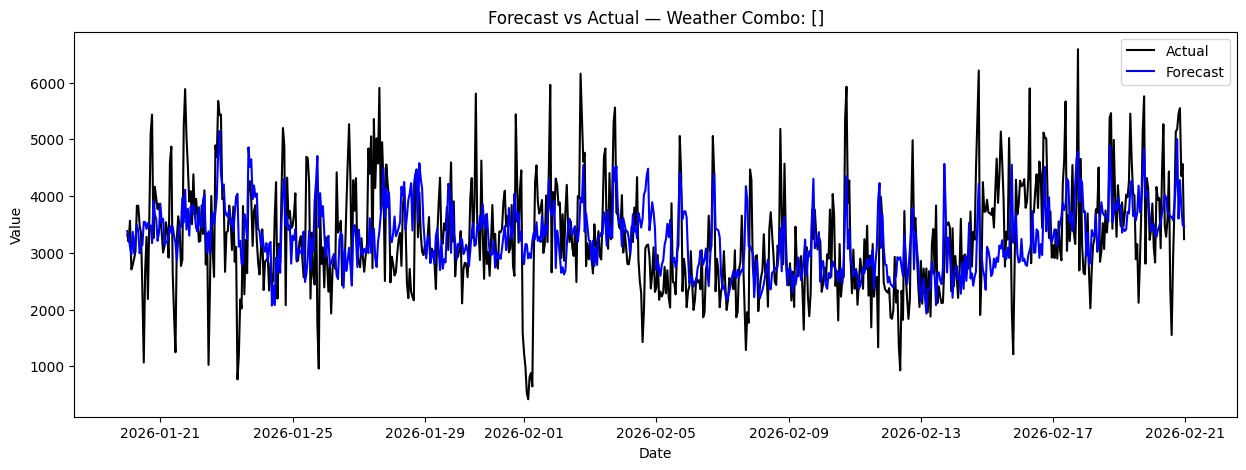

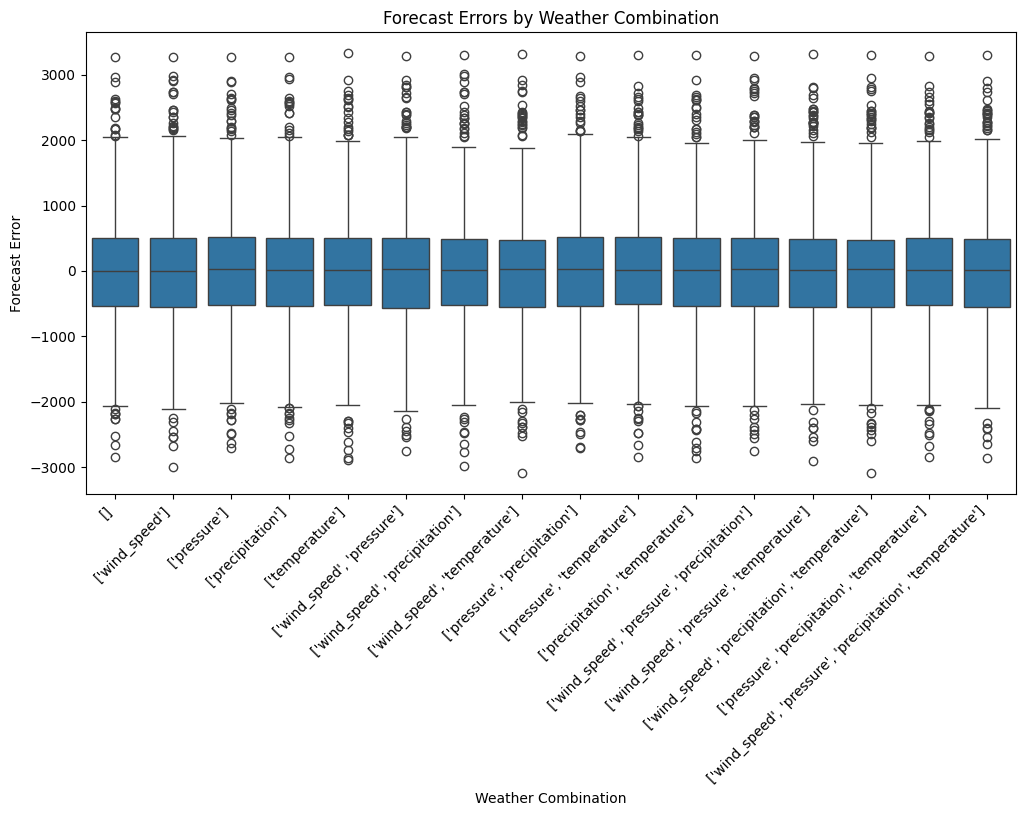

C:\Users\hp\AppData\Local\Temp\ipykernel_200080\4003757915.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_per_combo = all_forecasts_df.groupby('weather_combo_str').apply(
C:\Users\hp\AppData\Local\Temp\ipykernel_200080\4003757915.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mse_per_combo, x='weather_combo_str', y='mean_mse', palette='viridis')


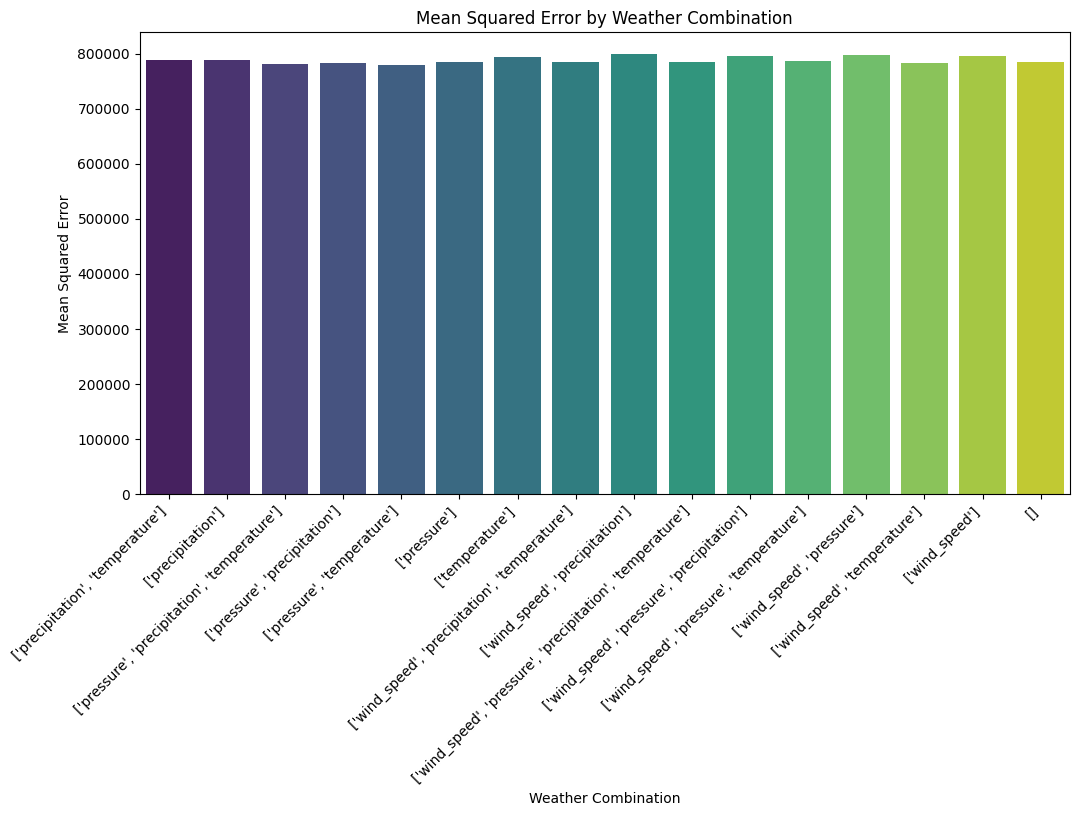

                                    weather_combo_str      mape
13                      ['wind_speed', 'temperature']  0.253403
0                    ['precipitation', 'temperature']  0.253532
7      ['wind_speed', 'precipitation', 'temperature']  0.253573
2        ['pressure', 'precipitation', 'temperature']  0.254001
4                         ['pressure', 'temperature']  0.254314
6                                     ['temperature']  0.255065
9   ['wind_speed', 'pressure', 'precipitation', 't...  0.255446
15                                                 []  0.255614
3                       ['pressure', 'precipitation']  0.255629
1                                   ['precipitation']  0.255762
11          ['wind_speed', 'pressure', 'temperature']  0.255984
5                                        ['pressure']  0.256703
14                                     ['wind_speed']  0.257405
8                     ['wind_speed', 'precipitation']  0.257686
10        ['wind_speed', 'pressure', 'pr

C:\Users\hp\AppData\Local\Temp\ipykernel_200080\4003757915.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mape_per_combo, x='weather_combo_str', y='mape', palette='coolwarm')


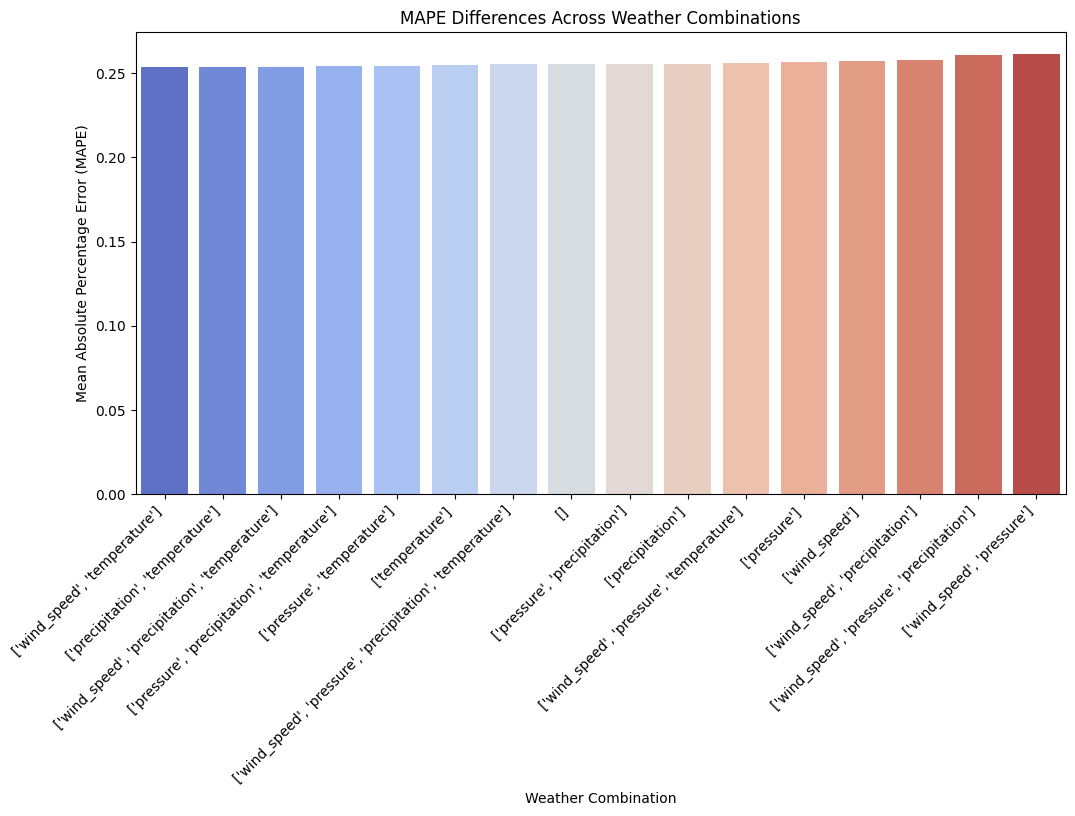

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# -----------------------------
# Load forecasts CSV
# -----------------------------
all_forecasts_df = pd.read_csv("wheater_all_forecasts_allow_no_temp_30d.csv", sep=';')
all_forecasts_df['date'] = pd.to_datetime(all_forecasts_df['date'])

# Convert weather_combo to string (if not already)
all_forecasts_df['weather_combo_str'] = all_forecasts_df['weather_combo'].astype(str)

# -----------------------------
# Compute forecast errors
# -----------------------------
all_forecasts_df['error'] = all_forecasts_df['forecast'] - all_forecasts_df['actual']

# -----------------------------
# 1. Plot forecast vs actual for a specific weather combination
# -----------------------------
def plot_forecast_vs_actual(combo_str):
    df_plot = all_forecasts_df[all_forecasts_df['weather_combo_str'] == combo_str]
    plt.figure(figsize=(15,5))
    plt.plot(df_plot['date'], df_plot['actual'], label='Actual', color='black')
    plt.plot(df_plot['date'], df_plot['forecast'], label='Forecast', color='blue')
    plt.title(f'Forecast vs Actual — Weather Combo: {combo_str}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# Example: plot first weather combo
example_combo_str = all_forecasts_df['weather_combo_str'].iloc[0]
plot_forecast_vs_actual(example_combo_str)

# -----------------------------
# 2. Boxplot of forecast errors for all weather combinations
# -----------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data=all_forecasts_df, x='weather_combo_str', y='error')
plt.xticks(rotation=45, ha='right')
plt.title('Forecast Errors by Weather Combination')
plt.ylabel('Forecast Error')
plt.xlabel('Weather Combination')
plt.show()

# -----------------------------
# 3. Mean Squared Error per weather combination
# -----------------------------
mse_per_combo = all_forecasts_df.groupby('weather_combo_str').apply(
    lambda x: mean_squared_error(x['actual'], x['forecast'])
).reset_index(name='mean_mse')

plt.figure(figsize=(12,6))
sns.barplot(data=mse_per_combo, x='weather_combo_str', y='mean_mse', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Mean Squared Error by Weather Combination')
plt.ylabel('Mean Squared Error')
plt.xlabel('Weather Combination')
plt.show()

all_forecasts_df['mape'] = np.abs(all_forecasts_df['forecast'] - all_forecasts_df['actual']) / all_forecasts_df['actual']
# Convert weather_combo to string if needed
all_forecasts_df['weather_combo_str'] = all_forecasts_df['weather_combo'].astype(str)

mape_per_combo = all_forecasts_df.groupby('weather_combo_str')['mape'].mean().reset_index()
mape_per_combo = mape_per_combo.sort_values('mape')
print(mape_per_combo)
plt.figure(figsize=(12,6))
sns.barplot(data=mape_per_combo, x='weather_combo_str', y='mape', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.xlabel('Weather Combination')
plt.title('MAPE Differences Across Weather Combinations')
plt.show()


Loaded 231 rows from 21 files


,Unnamed: 0,day,mape,real_total,forecast_total,abs_error,perc_error,step_hours,train_days
0,0,2026-02-10,3.780939,74965.98775,72575.022530,2390.965220,3.189400,12,120
1,1,2026-02-11,9.664831,64179.60800,70364.290529,6184.682529,9.636523,12,120
2,2,2026-02-12,16.738629,60030.19975,67814.671696,7784.471946,12.967593,12,120
3,3,2026-02-13,8.512466,65708.13725,61558.089000,4150.048250,6.315882,12,120
4,4,2026-02-14,12.090400,78509.39375,68195.532171,10313.861579,13.137105,12,120


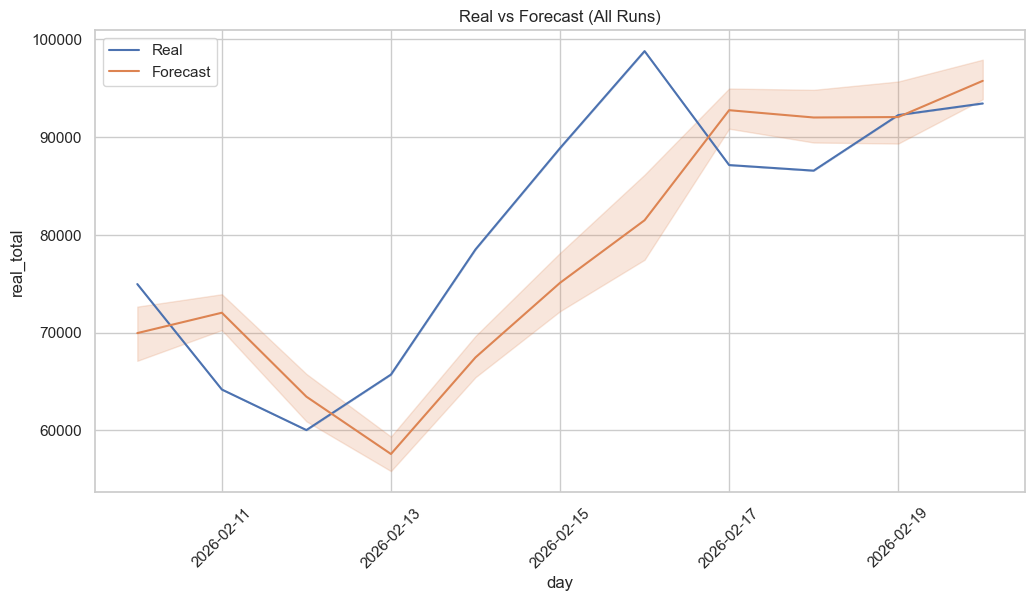

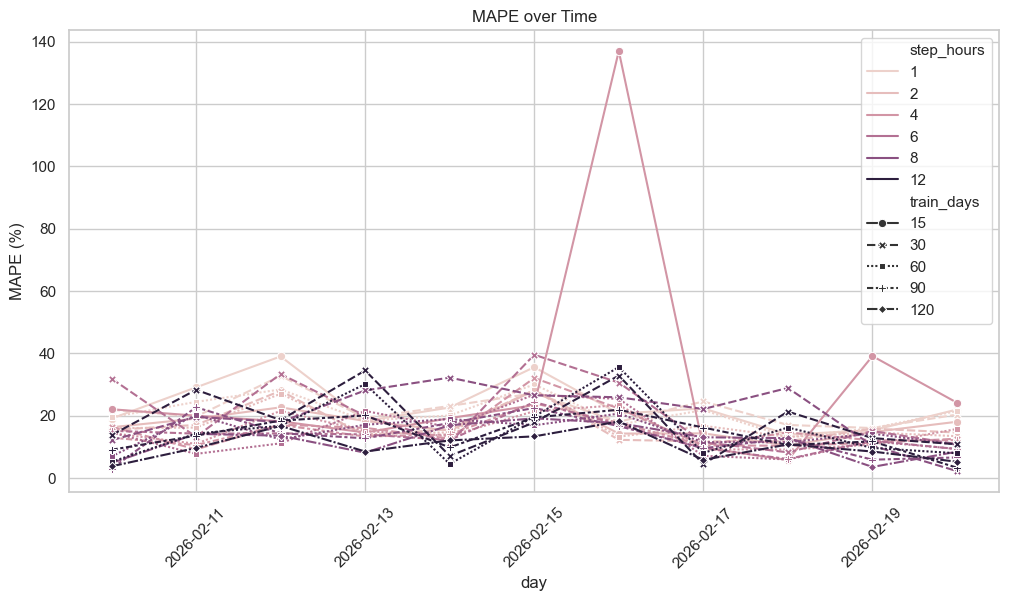

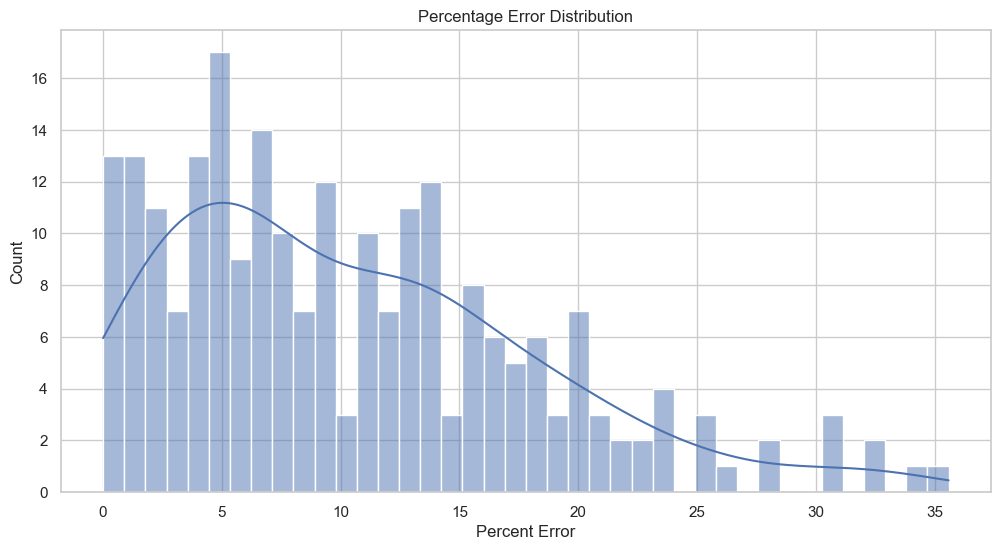

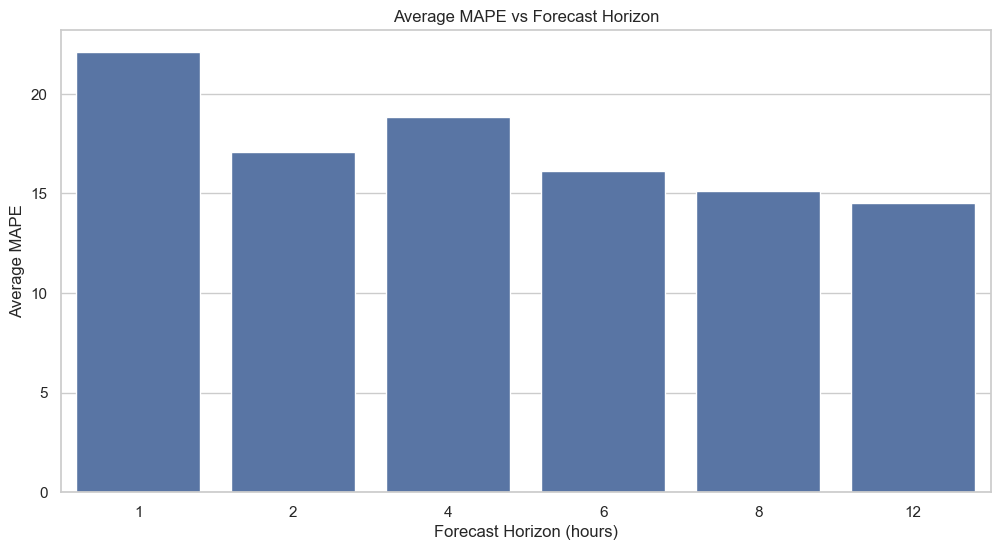

,step_hours,mape
0,1,22.094480
1,2,17.087894
2,4,18.840350
3,6,16.127797
4,8,15.110827
5,12,14.503732


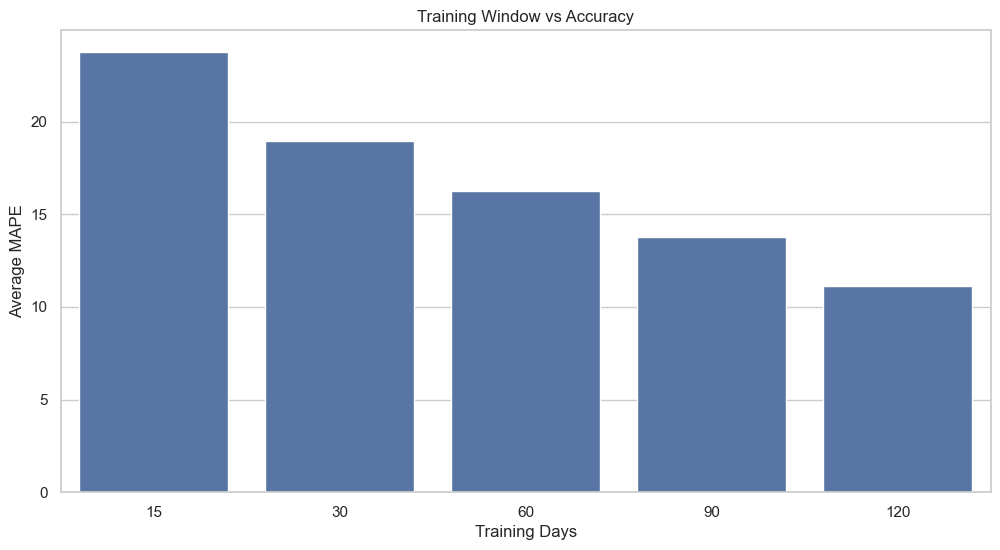

,train_days,mape
0,15,23.739902
1,30,18.948105
2,60,16.231012
3,90,13.790156
4,120,11.147561


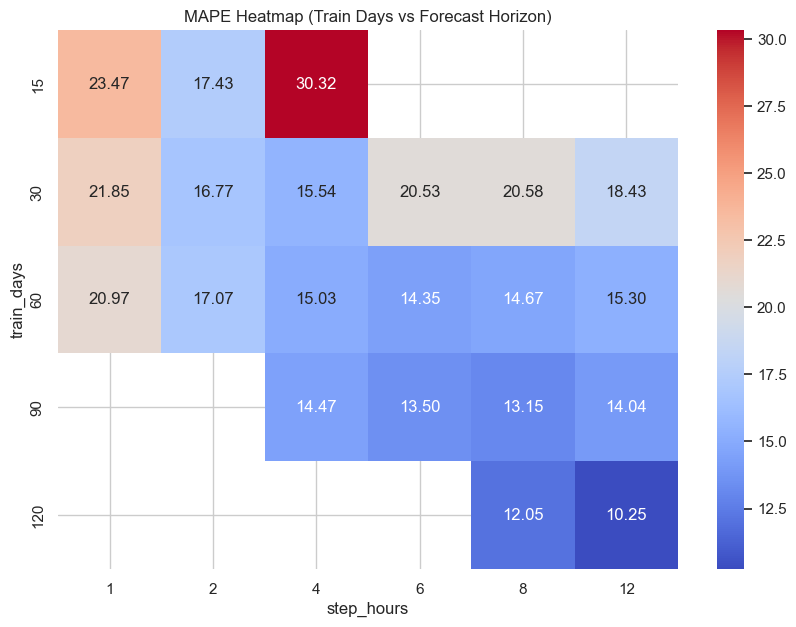

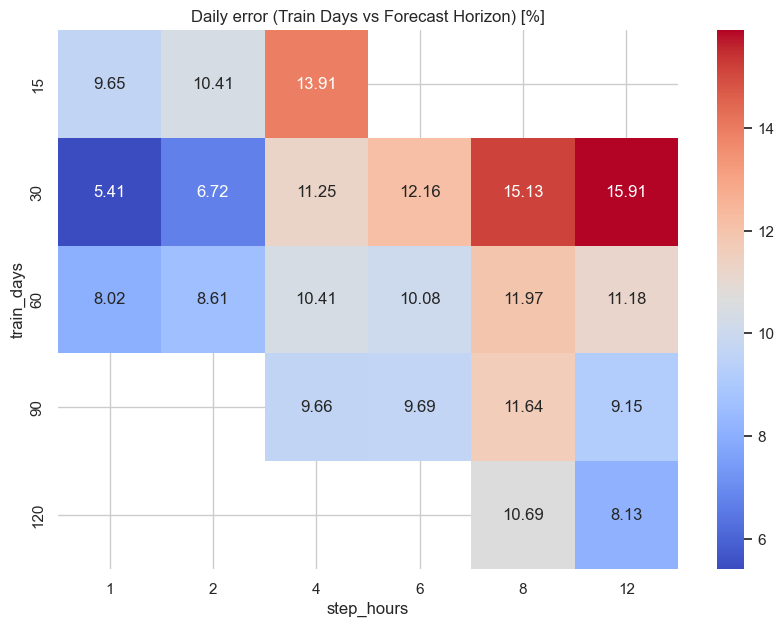

step_hours,1,2,4,6,8,12
train_days,,,,,,
15,9.651264,10.407333,13.912087,NaN,NaN,NaN
30,5.412237,6.716400,11.251637,12.156332,15.130209,15.907816
60,8.018922,8.606505,10.411315,10.075526,11.966906,11.178286
90,NaN,NaN,9.660735,9.686675,11.640096,9.150113
120,NaN,NaN,NaN,NaN,10.688834,8.131401


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
from pathlib import Path

# -------------------------
# Configuration
# -------------------------
DATA_DIR = "."
OUTPUT_DIR = "./plots"
SAVE_PLOTS = True

Path(OUTPUT_DIR).mkdir(exist_ok=True)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# -------------------------
# Load CSV files
# -------------------------
pattern = f"{DATA_DIR}/forecast_vs_real_*_h_step_*_days_update_data.csv"
files = glob.glob(pattern)

all_data = []

for file in files:

    match = re.search(r"forecast_vs_real_(\d+)_h_step_(\d+)_days_update_data", file)

    if not match:
        continue

    step_hours = int(match.group(1))
    train_days = int(match.group(2))

    df = pd.read_csv(file, sep=";")

    df["step_hours"] = step_hours
    df["train_days"] = train_days
    df["day"] = pd.to_datetime(df["day"])

    all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print(f"Loaded {len(data)} rows from {len(files)} files")
display(data.head())

# -----------------------------------
# Plot 1 — Real vs Forecast
# -----------------------------------

plt.figure()

sns.lineplot(data=data, x="day", y="real_total", label="Real")
sns.lineplot(data=data, x="day", y="forecast_total", label="Forecast")

plt.title("Real vs Forecast (All Runs)")
plt.xticks(rotation=45)

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/real_vs_forecast.png")

plt.show()

# -----------------------------------
# Plot 2 — MAPE over time
# -----------------------------------

plt.figure()

sns.lineplot(
    data=data,
    x="day",
    y="mape",
    hue="step_hours",
    style="train_days",
    markers=True
)

plt.title("MAPE over Time")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/mape_over_time.png")

plt.show()




# -----------------------------------
# Plot 3 — Error distribution
# -----------------------------------

plt.figure()

sns.histplot(data=data, x="perc_error", bins=40, kde=True)

plt.title("Percentage Error Distribution")
plt.xlabel("Percent Error")

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/error_distribution.png")

plt.show()

# -----------------------------------
# Plot 4 — Forecast horizon vs MAPE
# -----------------------------------

summary_horizon = (
    data.groupby("step_hours")["mape"]
    .mean()
    .reset_index()
)

plt.figure()

sns.barplot(data=summary_horizon, x="step_hours", y="mape")

plt.title("Average MAPE vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Average MAPE")

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/mape_vs_horizon.png")

plt.show()

display(summary_horizon)

# -----------------------------------
# Plot 5 — Training days vs MAPE
# -----------------------------------

summary_train = (
    data.groupby("train_days")["mape"]
    .mean()
    .reset_index()
)

plt.figure()

sns.barplot(data=summary_train, x="train_days", y="mape")

plt.title("Training Window vs Accuracy")
plt.xlabel("Training Days")
plt.ylabel("Average MAPE")

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/mape_vs_training_days.png")

plt.show()

display(summary_train)

# -----------------------------------
# Plot 6 — Heatmap comparison
# -----------------------------------

pivot = data.pivot_table(
    values="mape",
    index="train_days",
    columns="step_hours",
    aggfunc="mean"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("MAPE Heatmap (Train Days vs Forecast Horizon)")

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/mape_heatmap.png")

plt.show()

# -----------------------------------
# Plot 7 — Heatmap comparison daily 
# -----------------------------------

pivot = data.pivot_table(
    values="perc_error",
    index="train_days",
    columns="step_hours",
    aggfunc="mean"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Daily error (Train Days vs Forecast Horizon) [%]")

if SAVE_PLOTS:
    plt.savefig(f"{OUTPUT_DIR}/mape_heatmap.png")

plt.show()

display(pivot)

Loaded rows: 264


,TimeStamp,real,forecast
0,2026-02-10 00:00:00,2312.25700,3082.900497
1,2026-02-10 01:00:00,2445.75475,3102.325492
2,2026-02-10 02:00:00,2738.38875,2293.826421
3,2026-02-10 03:00:00,2507.56425,2735.848782
4,2026-02-10 04:00:00,2972.28575,2521.675434


,window,shift,MAE,RMSE,MAPE
28,12,7,2516.632658,3287.011229,6.551371
27,12,6,2788.113574,3261.233148,7.106339
24,12,3,2887.335094,3519.975470,7.233768
25,12,4,2919.094268,3486.034060,7.341230
26,12,5,2985.527441,3449.292878,7.600430
31,12,10,3077.791707,3719.940791,7.884533
29,12,8,3141.851400,3867.777674,7.913019
23,12,2,3215.121260,3906.968323,8.082082
22,12,1,3267.357021,4021.339745,8.158784
16,8,3,2152.975211,2735.698259,8.251426



=== AUTOMATIC INSIGHTS ===

🏆 Best overall configuration:
   Window = 12.0h, Shift = 7.0, MAPE = 6.55%

📉 Improvement vs hourly baseline:
   70.0% better than 1-hour windows

⏱️ Shift matters:
   Non-zero shifts improve accuracy → likely time misalignment

📊 Window size trend:
   1h → MAPE 21.85%
   2h → MAPE 15.65%
   4h → MAPE 11.17%
   6h → MAPE 9.68%
   8h → MAPE 8.25%
   12h → MAPE 6.55%



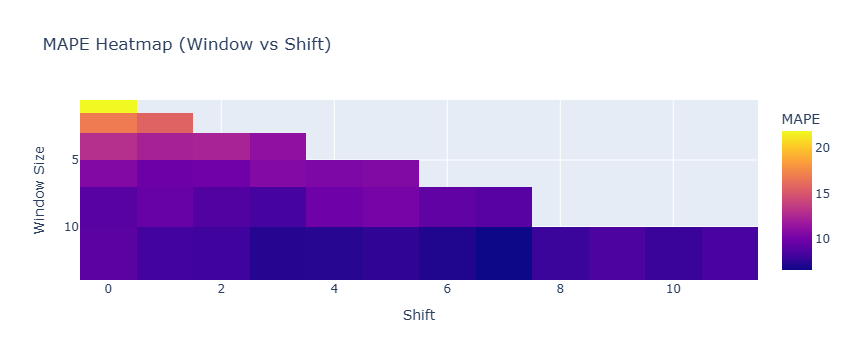

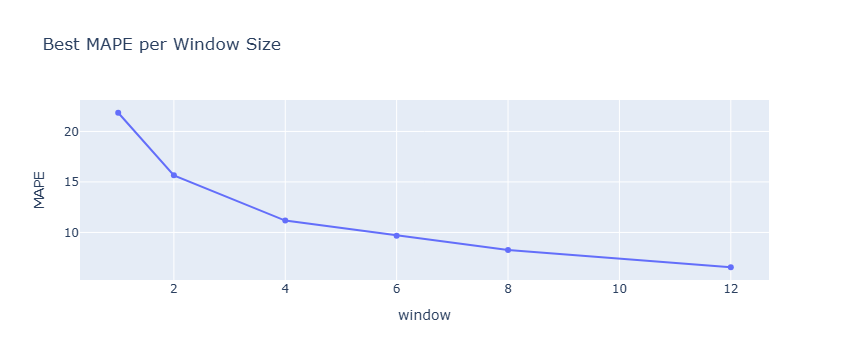

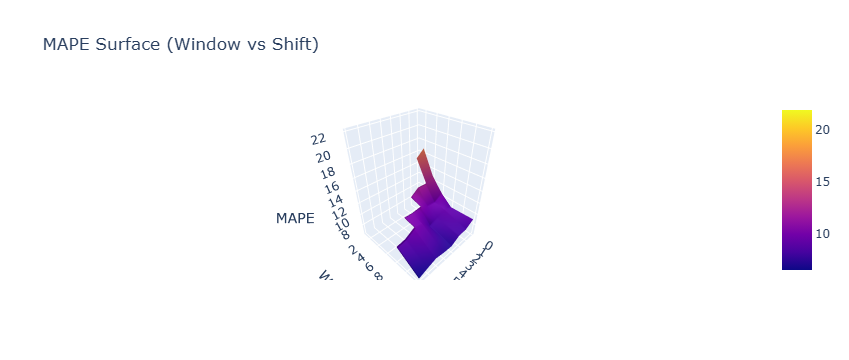


=== SHIFT IMPACT ===


,window,best_shift,shift0_MAPE,best_MAPE,abs_improvement,rel_improvement_%
0,12,7.0,9.061868,6.551371,2.510497,27.703971
1,8,3.0,8.964480,8.251426,0.713054,7.954215
2,6,1.0,10.589279,9.680715,0.908564,8.580037
3,4,3.0,12.919238,11.170055,1.749184,13.539372
4,2,1.0,16.840237,15.651058,1.189180,7.061537
5,1,0.0,21.847100,21.847100,0.000000,0.000000



=== SHIFT IMPORTANCE INSIGHT ===

📊 Average improvement from optimizing shift: 10.81%
🚨 Strong shift sensitivity detected → forecasts likely time-misaligned


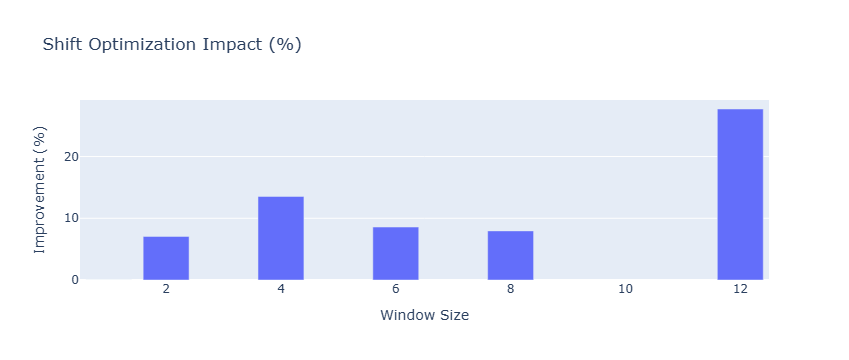

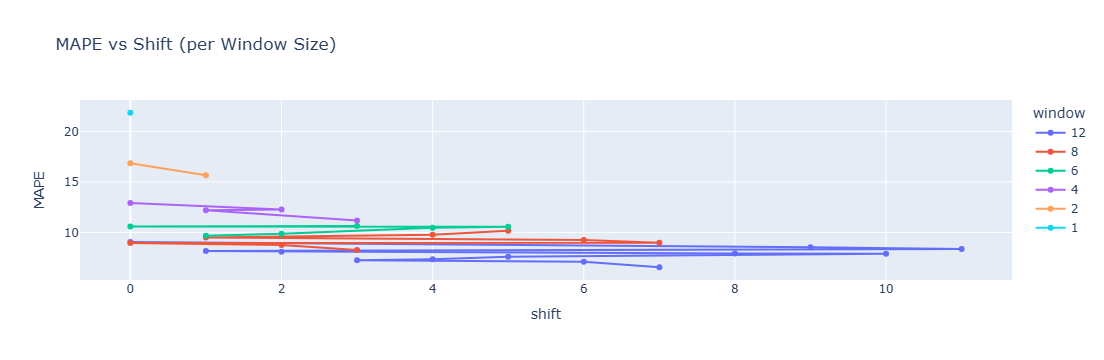


Most common best shift: [1. 3.]


In [71]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go

# -------------------------
# CONFIG
# -------------------------
DATA_DIR = "./forecast_vs_real_1_h_step_30_days_update_data"
WINDOW_SIZES = [1, 2, 4, 6, 8, 12]

# -------------------------
# LOAD DATA
# -------------------------
files = sorted(glob.glob(f"{DATA_DIR}/*.csv"))

dfs = []
for file in files:
    df = pd.read_csv(file, sep=";")
    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
    df = df.sort_values("TimeStamp")

    diffs = df["TimeStamp"].diff().dropna()
    if not (diffs == pd.Timedelta(hours=1)).all():
        print(f"Skipping {file}")
        continue

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Loaded rows:", len(data))
display(data.head())

# -------------------------
# EVALUATION FUNCTION
# -------------------------
def evaluate(df, window, shift):
    real = df["real"].values
    forecast = df["forecast"].values

    errors, abs_errors, mapes = [], [], []

    for start in range(shift, len(df) - window + 1, window):
        end = start + window

        r = real[start:end].sum()
        f = forecast[start:end].sum()

        err = f - r
        abs_err = abs(err)

        mape = abs_err / r * 100 if r != 0 else np.nan

        errors.append(err)
        abs_errors.append(abs_err)
        mapes.append(mape)

    if len(errors) == 0:
        return None

    return {
        "window": window,
        "shift": shift,
        "MAE": np.mean(abs_errors),
        "RMSE": np.sqrt(np.mean(np.array(errors) ** 2)),
        "MAPE": np.nanmean(mapes)
    }

# -------------------------
# RUN GRID SEARCH
# -------------------------
results = []

for w in WINDOW_SIZES:
    for s in range(w):
        res = evaluate(data, w, s)
        if res:
            results.append(res)

results_df = pd.DataFrame(results).sort_values("MAPE")

display(results_df.head(10))

# -------------------------
# BEST CONFIGS
# -------------------------
best = results_df.iloc[0]

best_per_window = (
    results_df.sort_values("MAPE")
    .groupby("window")
    .first()
    .reset_index()
)

# -------------------------
# 🧠 AUTOMATIC INSIGHTS
# -------------------------
print("\n=== AUTOMATIC INSIGHTS ===\n")

print(f"🏆 Best overall configuration:")
print(f"   Window = {best['window']}h, Shift = {best['shift']}, MAPE = {best['MAPE']:.2f}%\n")

# Compare smallest vs best
base_1h = results_df[results_df["window"] == 1]["MAPE"].min()
improvement = (base_1h - best["MAPE"]) / base_1h * 100

print(f"📉 Improvement vs hourly baseline:")
print(f"   {improvement:.1f}% better than 1-hour windows\n")

# Detect if shift matters
shift0 = results_df[results_df["shift"] == 0]["MAPE"].mean()
shift_best = results_df.groupby("window")["MAPE"].min().mean()

if shift_best < shift0:
    print("⏱️ Shift matters:")
    print("   Non-zero shifts improve accuracy → likely time misalignment\n")

# Trend of window size
print("📊 Window size trend:")
for _, row in best_per_window.iterrows():
    print(f"   {int(row['window'])}h → MAPE {row['MAPE']:.2f}%")

print()

# -------------------------
# 📊 INTERACTIVE DASHBOARD
# -------------------------

# Heatmap
pivot = results_df.pivot(index="window", columns="shift", values="MAPE")

fig_heatmap = px.imshow(
    pivot,
    labels=dict(x="Shift", y="Window Size", color="MAPE"),
    title="MAPE Heatmap (Window vs Shift)",
    aspect="auto"
)

fig_heatmap.show()

# Best per window plot
fig_line = px.line(
    best_per_window,
    x="window",
    y="MAPE",
    markers=True,
    title="Best MAPE per Window Size"
)

fig_line.show()

# 3D surface (very cool insight)
fig_3d = go.Figure(data=[go.Surface(
    z=pivot.values,
    x=pivot.columns,
    y=pivot.index
)])

fig_3d.update_layout(
    title="MAPE Surface (Window vs Shift)",
    scene=dict(
        xaxis_title="Shift",
        yaxis_title="Window",
        zaxis_title="MAPE"
    )
)

fig_3d.show()

# -------------------------
# 📊 SHIFT IMPACT ANALYSIS
# -------------------------

shift_impact = []

for w in results_df["window"].unique():
    subset = results_df[results_df["window"] == w]

    best_row = subset.loc[subset["MAPE"].idxmin()]
    shift0_row = subset[subset["shift"] == 0]

    if len(shift0_row) == 0:
        continue

    shift0_mape = shift0_row["MAPE"].values[0]
    best_mape = best_row["MAPE"]

    abs_improvement = shift0_mape - best_mape
    rel_improvement = abs_improvement / shift0_mape * 100

    shift_impact.append({
        "window": w,
        "best_shift": best_row["shift"],
        "shift0_MAPE": shift0_mape,
        "best_MAPE": best_mape,
        "abs_improvement": abs_improvement,
        "rel_improvement_%": rel_improvement
    })

shift_impact_df = pd.DataFrame(shift_impact)

print("\n=== SHIFT IMPACT ===")
display(shift_impact_df)

print("\n=== SHIFT IMPORTANCE INSIGHT ===\n")

avg_improvement = shift_impact_df["rel_improvement_%"].mean()

print(f"📊 Average improvement from optimizing shift: {avg_improvement:.2f}%")

if avg_improvement > 10:
    print("🚨 Strong shift sensitivity detected → forecasts likely time-misaligned")
elif avg_improvement > 3:
    print("⚠️ Moderate shift impact → some timing mismatch")
else:
    print("✅ Minimal shift impact → alignment is good")

import plotly.express as px

fig_shift = px.bar(
    shift_impact_df,
    x="window",
    y="rel_improvement_%",
    title="Shift Optimization Impact (%)",
    labels={"rel_improvement_%": "Improvement (%)", "window": "Window Size"}
)

fig_shift.show()

fig_shift_curve = px.line(
    results_df,
    x="shift",
    y="MAPE",
    color="window",
    markers=True,
    title="MAPE vs Shift (per Window Size)"
)

fig_shift_curve.show()

best_shifts = shift_impact_df["best_shift"]

print("\nMost common best shift:", best_shifts.mode().values)

if len(best_shifts.mode()) == 1:
    print("🧠 Consistent optimal shift detected → strong systematic lag")

filename: forecast_vs_real_2_h_step_7_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for varia

           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10  17.797546  74965.987750    79084.582693   4118.594943   
1   2026-02-11  26.979447  64179.608000    72964.851064   8785.243064   
2   2026-02-12  33.286329  60030.199750    71696.627030  11666.427280   
3   2026-02-13  22.220318  65708.137250    50188.666140  15519.471110   
4   2026-02-14  14.586574  78509.393750    68026.174140  10483.219610   
5   2026-02-15  28.682671  88874.440000    74113.961473  14760.478527   
6   2026-02-16  41.800542  98799.769750    98846.192689     46.422939   
7   2026-02-17  16.779366  87142.079250    81086.352163   6055.727087   
8   2026-02-18  20.544646  86570.285417    91506.449993   4936.164576   
9   2026-02-19  23.010362  92254.925250    90930.729021   1324.196229   
10  2026-02-20  15.251526  93444.755583    94405.700876    960.945293   

    perc_error  
0     5.493951  
1    13.688527  
2    19.434264  
3    23.618796  
4    13.352822  
5    16.608238  
6   

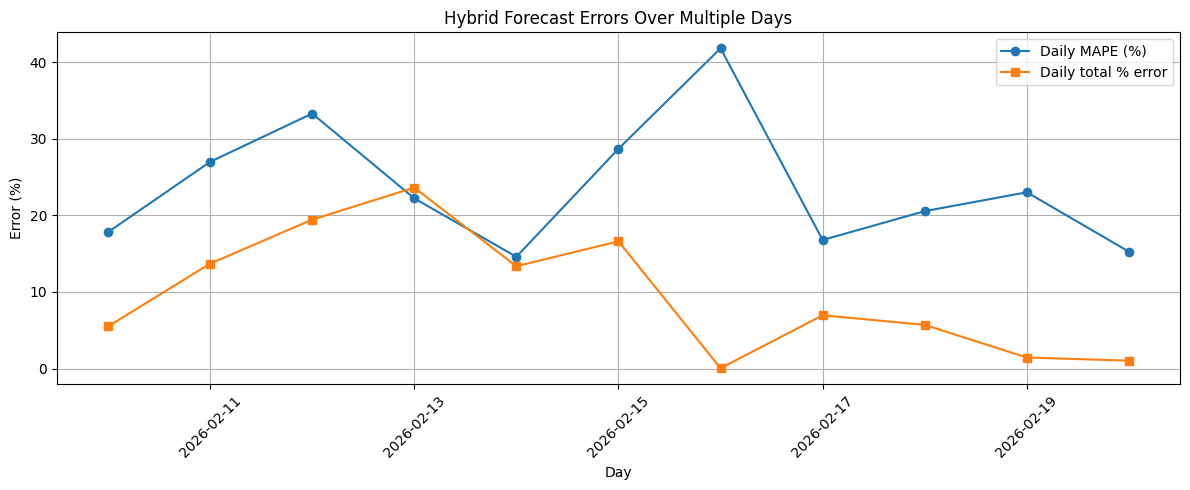

filename: forecast_vs_real_1_h_step_7_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftw

           day          mape    real_total  forecast_total     abs_error  \
0   2026-02-10  2.055522e+01  74965.987750    7.176158e+04  3.204410e+03   
1   2026-02-11  2.919080e+01  64179.608000    7.770157e+04  1.352197e+04   
2   2026-02-12  2.697891e+01  60030.199750    5.689281e+04  3.137387e+03   
3   2026-02-13  3.657815e+15  65708.137250   -3.449189e+17  3.449189e+17   
4   2026-02-14  2.152125e+01  78509.393750    7.566783e+04  2.841563e+03   
5   2026-02-15  2.577554e+01  88874.440000    8.680620e+04  2.068241e+03   
6   2026-02-16  2.036111e+01  98799.769750    8.683930e+04  1.196047e+04   
7   2026-02-17  2.225255e+01  87142.079250    8.129352e+04  5.848563e+03   
8   2026-02-18  1.615500e+01  86570.285417    7.922920e+04  7.341085e+03   
9   2026-02-19  1.896200e+01  92254.925250    1.019161e+05  9.661172e+03   
10  2026-02-20  1.819106e+01  93444.755583    8.624961e+04  7.195142e+03   

      perc_error  
0   4.274485e+00  
1   2.106894e+01  
2   5.226348e+00  
3   5.24925

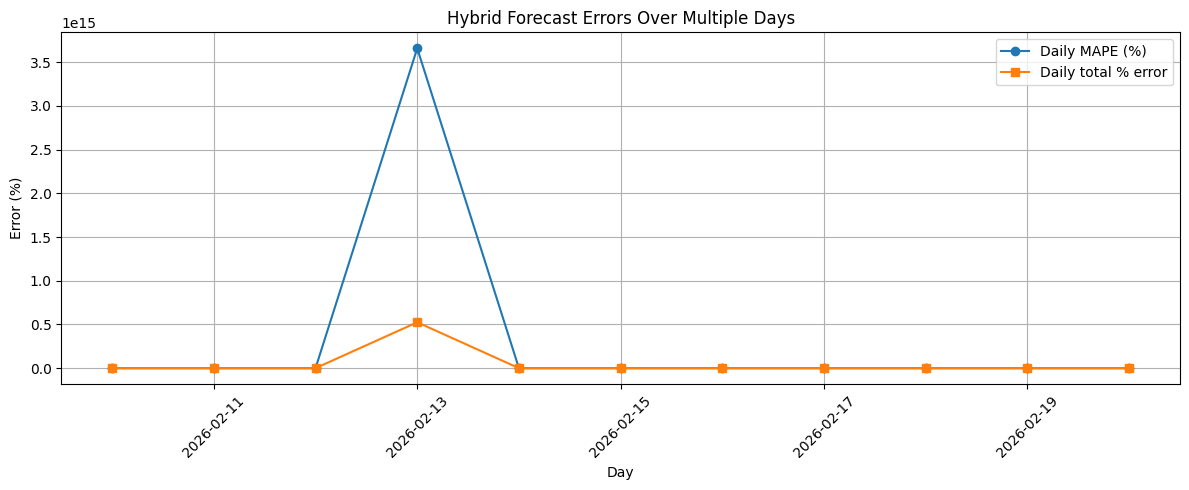

filename: forecast_vs_real_2_h_step_15_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate s

           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10  16.306415  74965.987750    66706.821912   8259.165838   
1   2026-02-11  19.085921  64179.608000    71589.010636   7409.402636   
2   2026-02-12  22.691998  60030.199750    65629.323343   5599.123593   
3   2026-02-13  18.329026  65708.137250    52630.374021  13077.763229   
4   2026-02-14  15.236683  78509.393750    66534.839254  11974.554496   
5   2026-02-15  28.084486  88874.440000    78081.665150  10792.774850   
6   2026-02-16  14.286789  98799.769750    89210.586144   9589.183606   
7   2026-02-17  14.351818  87142.079250    93901.128608   6759.049358   
8   2026-02-18  10.480354  86570.285417    91103.797615   4533.512198   
9   2026-02-19  14.780509  92254.925250    95831.796237   3576.870987   
10  2026-02-20  18.073194  93444.755583   101589.824554   8145.068970   

    perc_error  
0    11.017217  
1    11.544793  
2     9.327178  
3    19.902806  
4    15.252384  
5    12.143846  
6   

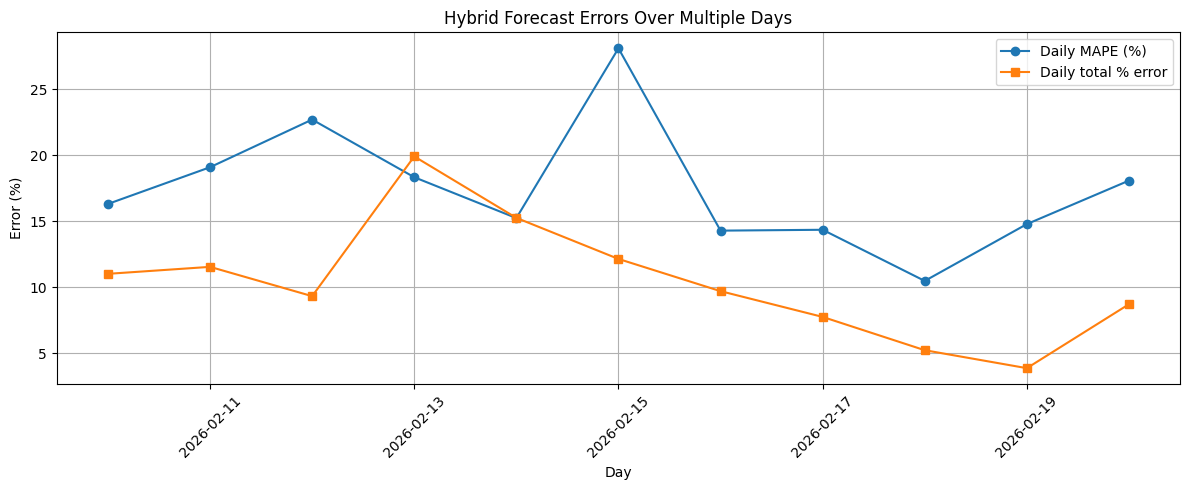

filename: forecast_vs_real_4_h_step_15_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate s

           day        mape    real_total  forecast_total     abs_error  \
0   2026-02-10   22.093574  74965.987750    73019.744381   1946.243369   
1   2026-02-11   20.027256  64179.608000    71335.696997   7156.088997   
2   2026-02-12   18.215116  60030.199750    68319.312940   8289.113190   
3   2026-02-13   14.625434  65708.137250    55592.185072  10115.952178   
4   2026-02-14   19.230728  78509.393750    63451.372626  15058.021124   
5   2026-02-15   23.417031  88874.440000    69846.509929  19027.930071   
6   2026-02-16  137.003814  98799.769750   114137.358251  15337.588501   
7   2026-02-17    9.825998  87142.079250    92913.748353   5771.669103   
8   2026-02-18    5.787511  86570.285417    90007.157052   3436.871635   
9   2026-02-19   39.147207  92254.925250   120238.374591  27983.449341   
10  2026-02-20   24.186786  93444.755583   105633.130576  12188.374993   

    perc_error  
0     2.596169  
1    11.150098  
2    13.808239  
3    15.395281  
4    19.179897  
5    21.4

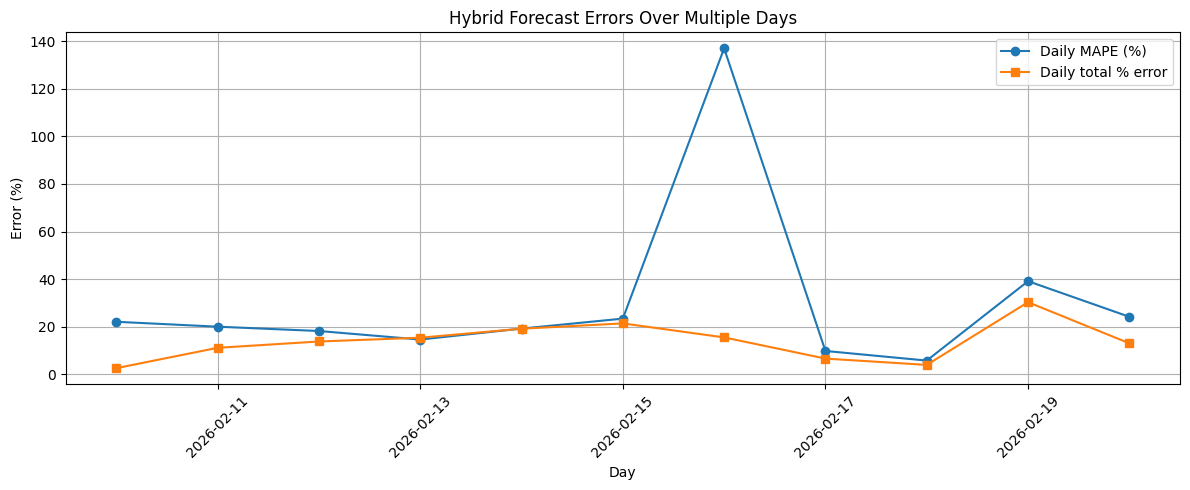

filename: forecast_vs_real_4_h_step_90_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10  12.965391  74965.987750    68931.725897   6034.261853   
1   2026-02-11  10.594316  64179.608000    68296.396581   4116.788581   
2   2026-02-12  17.067299  60030.199750    62467.155117   2436.955367   
3   2026-02-13  13.329875  65708.137250    58122.121844   7586.015406   
4   2026-02-14  13.991507  78509.393750    67135.634009  11373.759741   
5   2026-02-15  23.998856  88874.440000    67973.199819  20901.240181   
6   2026-02-16  17.743471  98799.769750    80226.158990  18573.610760   
7   2026-02-17  10.531509  87142.079250    91663.772993   4521.693743   
8   2026-02-18  14.669539  86570.285417    98502.476565  11932.191148   
9   2026-02-19  12.095389  92254.925250    92083.005149    171.920101   
10  2026-02-20  12.174111  93444.755583    93666.350562    221.594979   

    perc_error  
0     8.049333  
1     6.414481  
2     4.059549  
3    11.545017  
4    14.487132  
5    23.517718  
6   

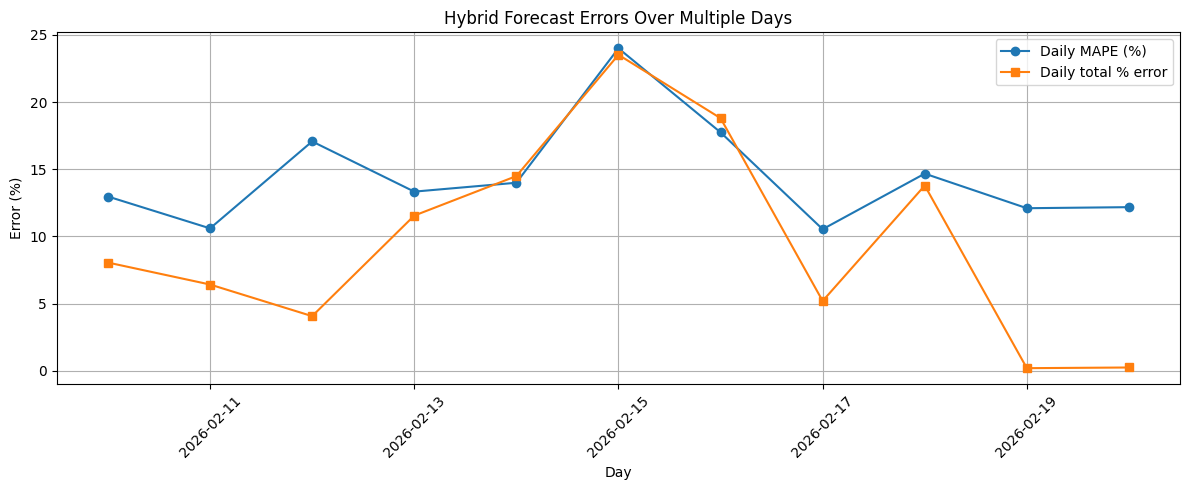

filename: forecast_vs_real_6_h_step_30_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate s

           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10  31.927598  74965.987750    50802.912708  24163.075042   
1   2026-02-11  13.265492  64179.608000    70323.868594   6144.260594   
2   2026-02-12  33.378870  60030.199750    51597.385622   8432.814128   
3   2026-02-13  20.000877  65708.137250    61546.307002   4161.830248   
4   2026-02-14  11.281771  78509.393750    71034.018932   7475.374818   
5   2026-02-15  39.574648  88874.440000    72819.230008  16055.209992   
6   2026-02-16  30.632431  98799.769750    68277.348128  30522.421622   
7   2026-02-17  11.521508  87142.079250    87531.384257    389.305007   
8   2026-02-18   8.257620  86570.285417    87650.322212   1080.036795   
9   2026-02-19  15.094370  92254.925250    88567.151669   3687.773581   
10  2026-02-20  10.916695  93444.755583   100323.260630   6878.505046   

    perc_error  
0    32.232051  
1     9.573540  
2    14.047620  
3     6.333813  
4     9.521631  
5    18.065048  
6   

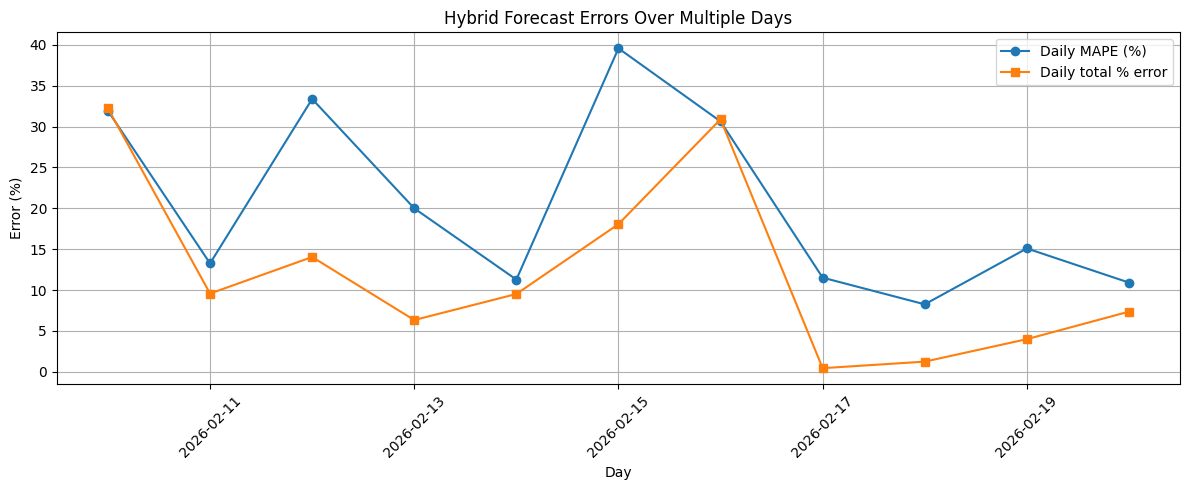

filename: forecast_vs_real_8_h_step_30_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10  12.139673  74965.987750    84647.771145   9681.783395   
1   2026-02-11  19.651368  64179.608000    77146.547812  12966.939812   
2   2026-02-12  18.016737  60030.199750    71121.093715  11090.893965   
3   2026-02-13  28.123933  65708.137250    55505.959288  10202.177962   
4   2026-02-14  32.240694  78509.393750    54424.836294  24084.557456   
5   2026-02-15  26.558573  88874.440000    87501.313318   1373.126682   
6   2026-02-16  25.929428  98799.769750    86652.229150  12147.540600   
7   2026-02-17  22.155860  87142.079250   106600.943801  19458.864551   
8   2026-02-18  28.921191  86570.285417   110552.057744  23981.772327   
9   2026-02-19  10.409631  92254.925250    89555.061640   2699.863610   
10  2026-02-20   2.239733  93444.755583    95159.610185   1714.854601   

    perc_error  
0    12.914901  
1    20.204143  
2    18.475524  
3    15.526506  
4    30.677294  
5     1.545019  
6   

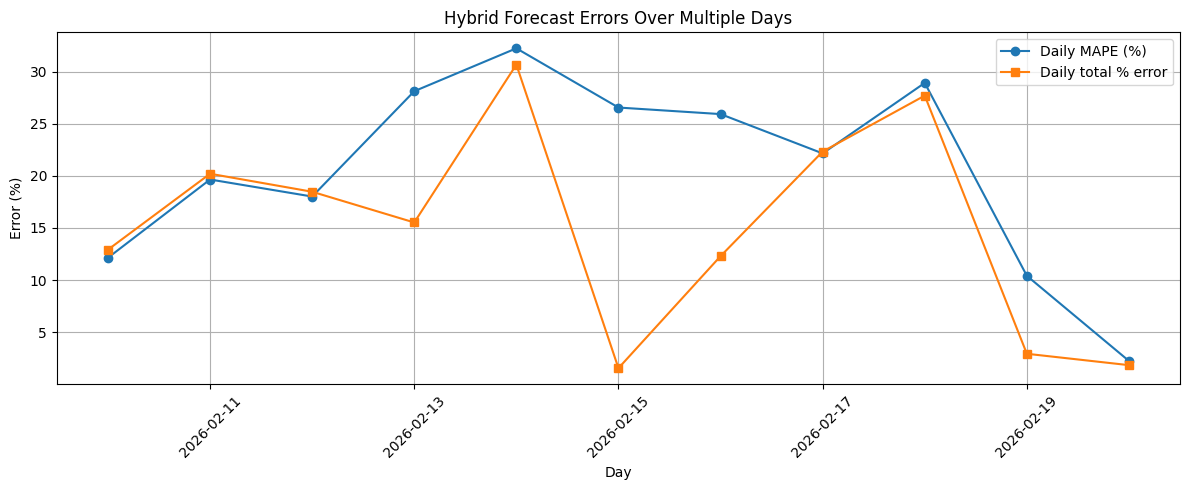

filename: forecast_vs_real_8_h_step_60_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10   6.949860  74965.987750    71391.462961   3574.524789   
1   2026-02-11  20.270702  64179.608000    77367.662993  13188.054993   
2   2026-02-12  12.397610  60030.199750    56970.959030   3059.240720   
3   2026-02-13  17.119356  65708.137250    54195.774062  11512.363188   
4   2026-02-14  18.957378  78509.393750    62796.787797  15712.605953   
5   2026-02-15  16.945527  88874.440000    73220.886510  15653.553490   
6   2026-02-16  20.686592  98799.769750    78176.862394  20622.907356   
7   2026-02-17  11.521441  87142.079250    95362.428669   8220.349419   
8   2026-02-18  11.522863  86570.285417    95526.306678   8956.021261   
9   2026-02-19  14.269231  92254.925250    91268.897496    986.027754   
10  2026-02-20  10.714153  93444.755583    89375.415866   4069.339717   

    perc_error  
0     4.768195  
1    20.548669  
2     5.096169  
3    17.520453  
4    20.013664  
5    17.613111  
6   

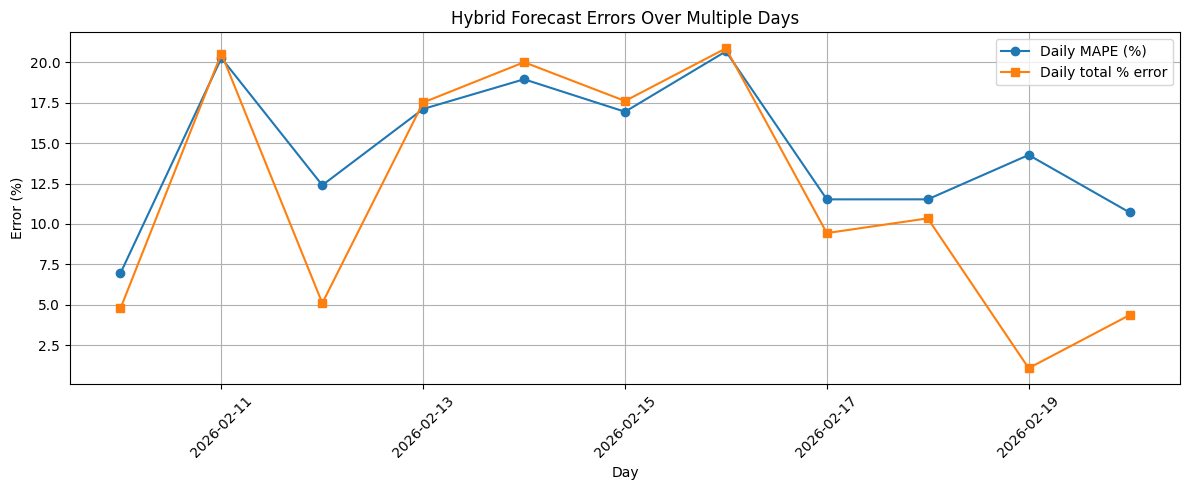

filename: forecast_vs_real_8_h_step_90_days_update_data
           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10   3.036393  74965.987750    73954.124315   1011.863435   
1   2026-02-11  22.733089  64179.608000    79136.733532  14957.125532   
2   2026-02-12  14.398713  60030.199750    57193.329759   2836.869991   
3   2026-02-13  12.762329  65708.137250    57431.965295   8276.171955   
4   2026-02-14  17.684976  78509.393750    64114.842165  14394.551585   
5   2026-02-15  22.495967  88874.440000    68287.801215  20586.638785   
6   2026-02-16  16.685638  98799.769750    82061.802432  16737.967318   
7   2026-02-17   9.578042  87142.079250    91705.303550   4563.224300   
8   2026-02-18  12.726693  86570.285417    96687.236189  10116.950772   
9   2026-02-19   5.903748  92254.925250    86864.477382   5390.447868   
10  2026-02-20   6.625527  93444.755583    88903.976607   4540.778976   

    perc_error  
0     1.349763  
1    23.305106  
2     4.725738  

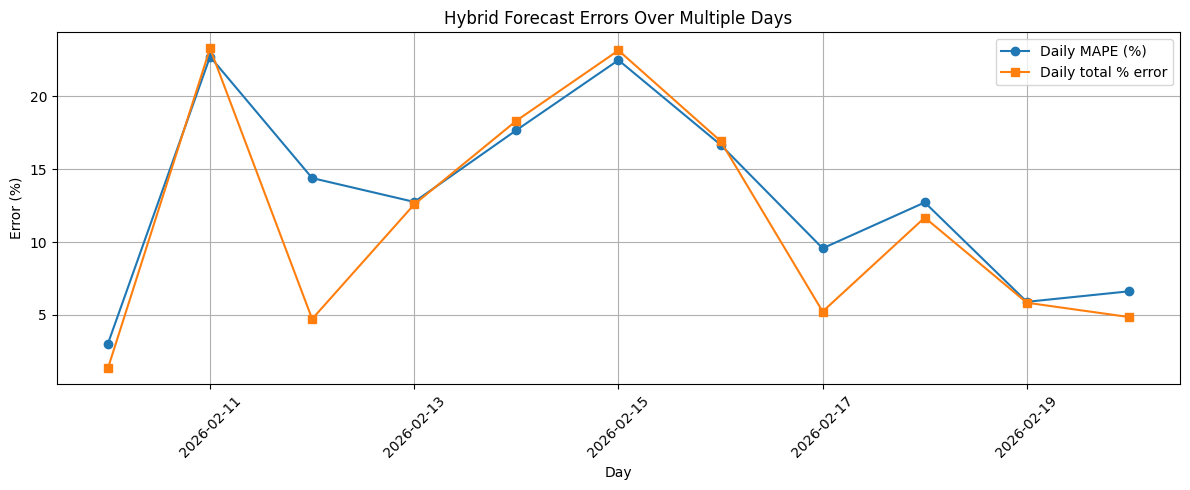

filename: forecast_vs_real_8_h_step_120_days_update_data
           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10   4.825353  74965.987750    71575.776416   3390.211334   
1   2026-02-11  14.184465  64179.608000    73450.966897   9271.358897   
2   2026-02-12  13.598393  60030.199750    62690.859102   2660.659352   
3   2026-02-13   8.156061  65708.137250    60138.923000   5569.214250   
4   2026-02-14  16.951611  78509.393750    64484.721396  14024.672354   
5   2026-02-15  19.172275  88874.440000    71061.229676  17813.210324   
6   2026-02-16  17.644366  98799.769750    81120.398709  17679.371041   
7   2026-02-17  13.100326  87142.079250    97595.691797  10453.612547   
8   2026-02-18  12.823893  86570.285417    96824.104453  10253.819036   
9   2026-02-19   3.577310  92254.925250    88969.068000   3285.857250   
10  2026-02-20   8.469690  93444.755583    91110.713146   2334.042438   

    perc_error  
0     4.522333  
1    14.445958  
2     4.432201 

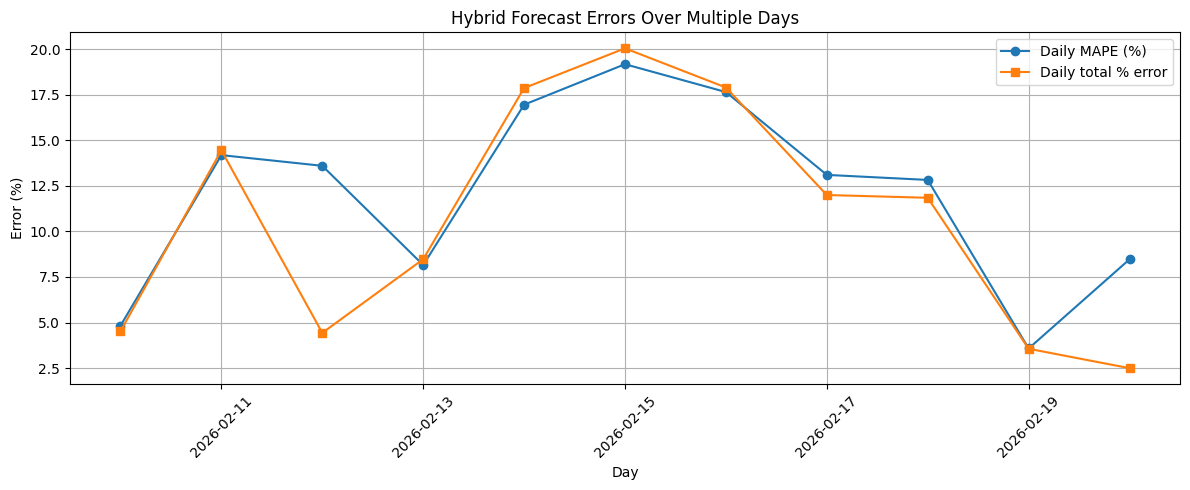

filename: forecast_vs_real_12_h_step_30_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate s

           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10  13.799669  74965.987750    64743.699178  10222.288572   
1   2026-02-11  28.328548  64179.608000    82336.661343  18157.053343   
2   2026-02-12  18.622289  60030.199750    60953.515722    923.315972   
3   2026-02-13  34.526644  65708.137250    49270.507791  16437.629459   
4   2026-02-14   7.128302  78509.393750    72836.316866   5673.076884   
5   2026-02-15  17.859345  88874.440000    71405.021773  17469.418227   
6   2026-02-16  32.894376  98799.769750    66301.580942  32498.188808   
7   2026-02-17   4.494268  87142.079250    85712.223252   1429.855998   
8   2026-02-18  21.343424  86570.285417   104904.396816  18334.111399   
9   2026-02-19  12.827198  92254.925250   104307.189088  12052.263838   
10  2026-02-20  10.857611  93444.755583   103580.136594  10135.381011   

    perc_error  
0    13.635902  
1    28.291001  
2     1.538086  
3    25.016125  
4     7.225985  
5    19.656291  
6   

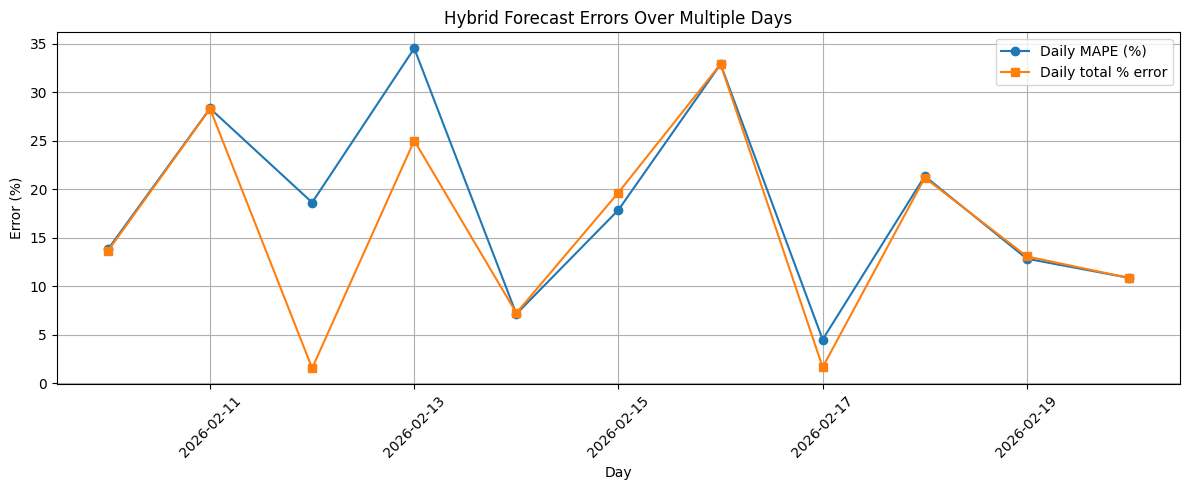

filename: forecast_vs_real_12_h_step_60_days_update_data


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hp\AppData\Local\Packages\PythonSoftw

           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10   5.218274  74965.987750    78838.774484   3872.786734   
1   2026-02-11  14.254644  64179.608000    73311.193413   9131.585413   
2   2026-02-12  16.806870  60030.199750    67847.029636   7816.829886   
3   2026-02-13  30.156121  65708.137250    48401.064321  17307.072929   
4   2026-02-14   4.549147  78509.393750    81520.720837   3011.327087   
5   2026-02-15  19.778265  88874.440000    79169.016210   9705.423790   
6   2026-02-16  35.605076  98799.769750    63652.670123  35147.099627   
7   2026-02-17   8.084392  87142.079250    88016.933950    874.854700   
8   2026-02-18  16.218911  86570.285417    86742.702258    172.416841   
9   2026-02-19   9.675664  92254.925250    87931.263515   4323.661735   
10  2026-02-20   7.963648  93444.755583   100907.520745   7462.765161   

    perc_error  
0     5.166058  
1    14.228173  
2    13.021496  
3    26.339315  
4     3.835626  
5    10.920377  
6   

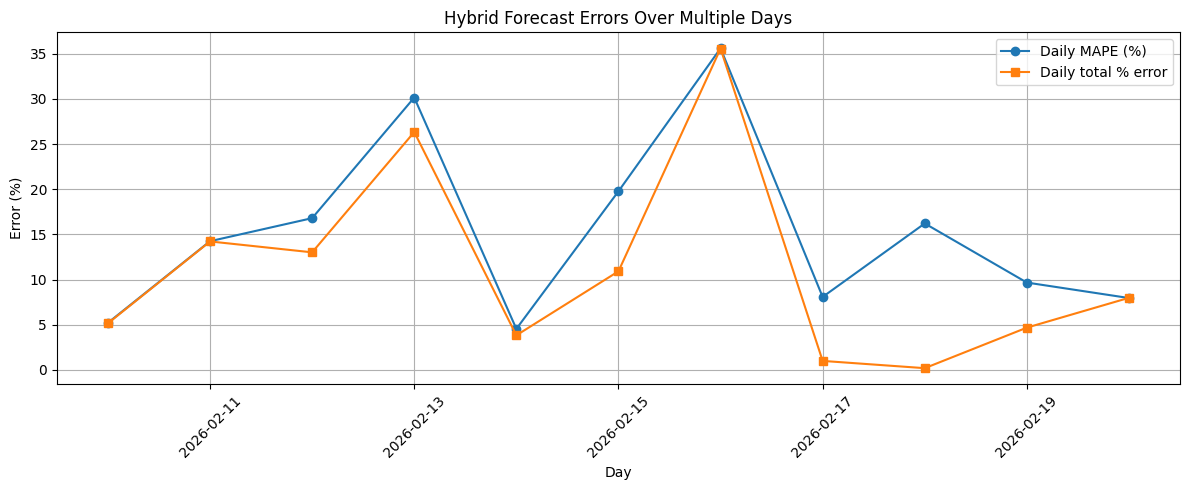

filename: forecast_vs_real_12_h_step_90_days_update_data
           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10   9.095057  74965.987750    78000.023264   3034.035514   
1   2026-02-11  13.617148  64179.608000    72894.507683   8714.899683   
2   2026-02-12  18.448643  60030.199750    69735.683523   9705.483773   
3   2026-02-13  20.082793  65708.137250    64758.558246    949.579004   
4   2026-02-14   9.845786  78509.393750    70111.846923   8397.546827   
5   2026-02-15  19.478768  88874.440000    82415.726315   6458.713685   
6   2026-02-16  21.921780  98799.769750    77153.518162  21646.251588   
7   2026-02-17  16.221322  87142.079250   101318.073411  14175.994161   
8   2026-02-18  10.618535  86570.285417    91292.403613   4722.118196   
9   2026-02-19  11.764904  92254.925250    91845.666858    409.258392   
10  2026-02-20   3.334203  93444.755583    96597.252263   3152.496679   

    perc_error  
0     4.047216  
1    13.578923  
2    16.167669 

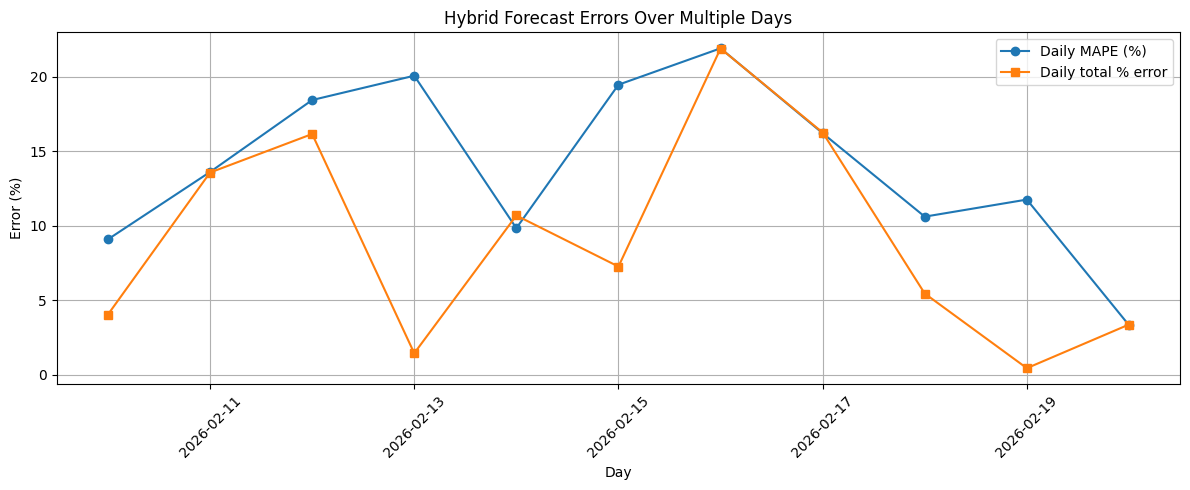

filename: forecast_vs_real_12_h_step_120_days_update_data
           day       mape    real_total  forecast_total     abs_error  \
0   2026-02-10   3.780939  74965.987750    72575.022530   2390.965220   
1   2026-02-11   9.664831  64179.608000    70364.290529   6184.682529   
2   2026-02-12  16.738629  60030.199750    67814.671696   7784.471946   
3   2026-02-13   8.512466  65708.137250    61558.089000   4150.048250   
4   2026-02-14  12.090400  78509.393750    68195.532171  10313.861579   
5   2026-02-15  13.381132  88874.440000    80087.749931   8786.690069   
6   2026-02-16  18.166602  98799.769750    80852.485053  17947.284697   
7   2026-02-17   5.847292  87142.079250    92247.545432   5105.466182   
8   2026-02-18  10.795630  86570.285417    88144.787598   1574.502181   
9   2026-02-19   8.521605  92254.925250    89180.733960   3074.191290   
10  2026-02-20   5.243071  93444.755583    98245.145078   4800.389494   

    perc_error  
0     3.189400  
1     9.636523  
2    12.967593

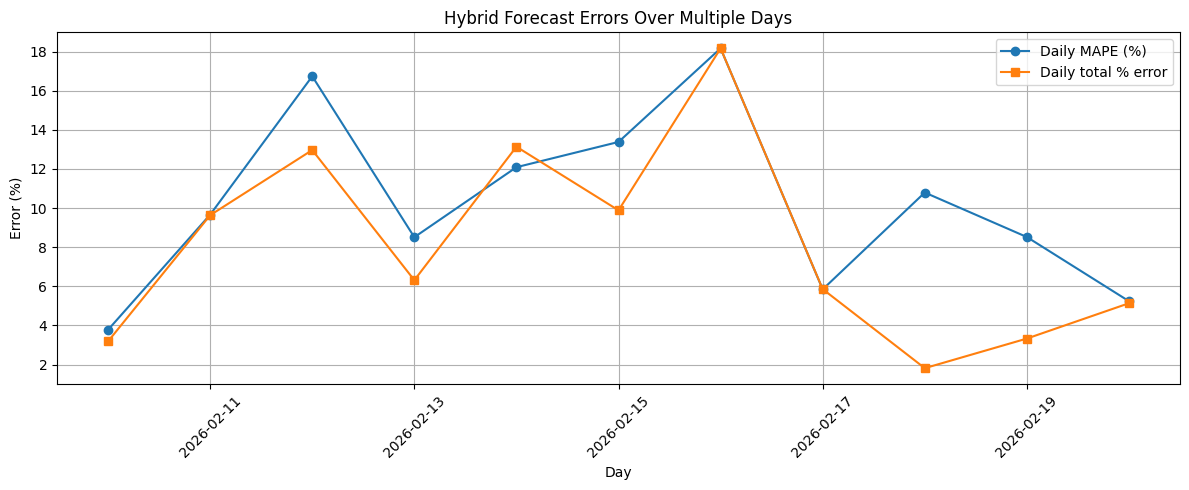

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Load CSV
# -----------------------------
VALUE_COL = "P_HOME"
TEMP_COL = "temperature"
FORECAST_HOURS = 24
show_plot = False

df = pd.read_csv("data_with_weather.csv", sep=";", parse_dates=["TimeStamp"])
df = df.set_index("TimeStamp")
df = df.asfreq('h') 

df[VALUE_COL] = df[VALUE_COL].interpolate(method='time').ffill().bfill()
df[TEMP_COL] = df[TEMP_COL].interpolate(method='time').ffill().bfill()

variants = [(2, 7), (1, 7), (2, 15), (4, 15), (4, 90), (6, 30), (8, 30), (8, 60), (8, 90), (8, 120), (12, 30), (12, 60), (12, 90), (12, 120)]

for variant in variants:
    STEP_HOURS, MONTH_LENGTH = variant
    filename = f"forecast_vs_real_{STEP_HOURS}_h_step_{MONTH_LENGTH}_days_update_data"
    print(f"filename: {filename}")
    # Store metrics
    all_results = []
    
    # List of days to forecast (e.g., 2026-02-01 to 2026-02-15)
    forecast_days = pd.date_range("2026-02-10", "2026-02-20", freq="D")
    
    train_end = forecast_days[0] - pd.Timedelta(hours=STEP_HOURS)
    train_start = train_end - pd.Timedelta(days=MONTH_LENGTH)
    
    # best_order, best_seasonal_order = find_best_sarimax_params(df.loc[train_start:train_end][VALUE_COL], STEP_HOURS)
    
    for day in forecast_days:
        # Select last 30 days of data for training (before this day)
        train_end = day - pd.Timedelta(hours=1)
        train_start = train_end - pd.Timedelta(days=MONTH_LENGTH)
        
        train_df = df.loc[train_start:train_end]
        # train_df = train_df.asfreq('h')
        
        # Skip if not enough data
        if len(train_df) < MONTH_LENGTH*24:
            continue
        # Get real temperature for the next 24 hours
        future_temp = df.loc[day : day + pd.Timedelta(hours=23), "temperature"]
        
        # Generate forecast for next day
        forecast_df = hybrid_24h_forecast(
            df=train_df,
            value_col=VALUE_COL,
            temperature_col=TEMP_COL,
            step_hours=STEP_HOURS,
            future_temp=future_temp,
            # best_order=best_order,
            # best_seasonal_order=best_seasonal_order
        )
        
        # Get real data for the forecast day
        df_resampled = df.resample(f"{STEP_HOURS}h").agg({
            VALUE_COL: lambda x: x.sum(min_count=1),      # energy consumption
            TEMP_COL: "mean"
        })
        real_df = df_resampled.loc[day:day + pd.Timedelta(hours=23)][VALUE_COL]
        
        # Align forecast with real data
        # forecast_df = forecast_df.loc[real_df.index]
    
        forecast_df = forecast_df.reindex(real_df.index)
        forecast_df['forecast'] = forecast_df['forecast'].interpolate(method='time').ffill().bfill()
        
        # Compute metrics
        mape = mean_absolute_percentage_error(real_df, forecast_df["forecast"]) * 100
        real_total = real_df.sum()
        forecast_total = forecast_df["forecast"].sum()
        abs_error = abs(real_total - forecast_total)
        perc_error = (abs_error / real_total) * 100
        
        # Store results
        all_results.append({
            "day": day.date(),
            "mape": mape,
            "real_total": real_total,
            "forecast_total": forecast_total,
            "abs_error": abs_error,
            "perc_error": perc_error
        })
        
        # Optional: plot each day
        if show_plot:
            plt.figure(figsize=(10,4))
            plt.plot(real_df.index, real_df.values, label="Real")
            plt.plot(forecast_df.index, forecast_df["forecast"], label="Forecast")
            plt.title(f"Hybrid Forecast vs Real - {day.date()} | MAPE: {mape:.2f}%")
            plt.xlabel("Time")
            plt.ylabel("Consumption")
            plt.legend()
            plt.grid(True)
            plt.show()
    
        # SAVE DATA
        comparison_df = pd.concat([real_df, forecast_df['forecast']], axis=1)
        comparison_df.columns = ['real', 'forecast']
        Path(filename).mkdir(exist_ok=True)
        comparison_df.to_csv(filename + "/" + day.strftime("%Y-%m-%d") +".csv", sep=";", index=True)
        
    
    # -----------------------------
    # Summary
    # -----------------------------
    results_df = pd.DataFrame(all_results)
    print(results_df)
    print("Average MAPE:", results_df["mape"].mean())
    print("Average daily percentage error:", results_df["perc_error"].mean())
    # -----------------------------
    # Plot errors across multiple days
    # -----------------------------
    plt.figure(figsize=(12,5))
    plt.plot(results_df['day'], results_df['mape'], marker='o', label='Daily MAPE (%)')
    plt.plot(results_df['day'], results_df['perc_error'], marker='s', label='Daily total % error')
    plt.xticks(rotation=45)
    plt.xlabel("Day")
    plt.ylabel("Error (%)")
    plt.title("Hybrid Forecast Errors Over Multiple Days")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # SAVE DATA
    results_df.to_csv(filename + ".csv", sep=";", index=True)